# Experiment A - Do layer descriptors improve property prediction?
## A paired, repeated grouped-CV feature-ablation study

**Repository:** [`cookms/squarenet_ml`](https://github.com/cookms/squarenet_ml)  
**Question:** after controlling for composition and inexpensive global crystal descriptors, do square-net detector outputs add reproducible predictive signal for materials properties?

This notebook is designed as a reproducible experiment rather than a leaderboard exercise. It compares five pre-registered feature sets on the **same material cohort, the same grouped splits, the same preprocessing, and the same model specification**. The central outputs are uncertainty intervals and paired split-level differences, not a single best score.

| Experiment element | Pre-registered choice |
|---|---|
| Unit of analysis | One material per row |
| Leakage group | Reduced formula by default; configurable |
| Feature comparison | Baseline; baseline + detector label; baseline + geometry; baseline + chemistry; combined |
| Regression targets | Band gap, energy above hull, formation energy per atom when present |
| Classification targets | Metal/nonmetal, near-hull stability, optional synthesized/experimental status |
| Primary models | Ridge regression and class-balanced logistic regression |
| Validation | Repeated stratified grouped K-fold, generated once per target and reused verbatim |
| Uncertainty | 95% bootstrap interval over repeat-level mean scores |
| Paired comparison | Fold-aligned improvement relative to the baseline; positive always means better |


## Scientific hypotheses and interpretation rule

The feature sets are **baseline-anchored ablations**: every extension contains the same baseline, while the combined set contains all families.

- **H0:** layer descriptors do not improve out-of-group property prediction beyond composition and global crystal descriptors.
- **H1-geometry:** geometric square-net descriptors add predictive information.
- **H1-chemistry:** layer chemistry and CrystalNN summaries add predictive information.
- **H1-combined:** the union of detector label, layer geometry, and layer chemistry produces the most reliable improvement.

For each target, the notebook reports the fold-level paired improvement and a 95% interval computed from repeat-level averages. A descriptive evidence label is assigned as follows:

- **Consistent improvement:** interval is entirely above zero and at least 60% of paired folds improve.
- **Inconclusive:** interval overlaps zero.
- **Consistent degradation:** interval is entirely below zero.

This is an estimation-first rubric, not a claim of formal statistical significance. Repeated CV folds are correlated, so the notebook avoids naive independent-fold p-values.

## Experiment setup and reusable modules

Implementation-heavy logic is separated into small Python modules so this notebook can emphasize the **scientific question, data audit, exploratory analysis, experimental design, model diagnostics, and conclusions**.

- `experiment_config.py` - pre-registered experiment settings.
- `featurization.py` - composition descriptors, JSON-count summaries, and leakage-group normalization.
- `experiment_protocol.py` - grouped splits, preprocessing, model fitting, metrics, and paired uncertainty summaries.
- `notebook_utils.py` - lightweight I/O, plotting, target-audit, and error-analysis helpers.


In [36]:
from pathlib import Path
import sys
import os

# Find repository root regardless of whether Jupyter started
# in the repo root or in notebooks/
cwd = Path.cwd().resolve()

if (cwd / "squarenet").is_dir():
    REPO_ROOT = cwd
elif (cwd.parent / "squarenet").is_dir():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(
        f"Could not locate the repository root from {cwd}. "
        "Expected to find a 'squarenet' directory."
    )

# Make repository package importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)

print(f"Current working directory: {Path.cwd()}")
print(f"Repository root: {REPO_ROOT}")
print(f"squarenet package: {REPO_ROOT / 'squarenet'}")

OUTPUT_DIR = REPO_ROOT / "outputs" / "experiment_A"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Current working directory: C:\Users\mscoo\GIT_projects\Squarenet_ML
Repository root: C:\Users\mscoo\GIT_projects\Squarenet_ML
squarenet package: C:\Users\mscoo\GIT_projects\Squarenet_ML\squarenet


In [2]:
from __future__ import annotations
import re
import warnings
from typing import Iterable, Sequence
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from squarenet.featurization import (
    add_composition_features, expand_json_count_features, 
    normalize_cv_groups, add_mp_property_features
)
from squarenet.experiment_protocol import (
    LOWER_IS_BETTER, PRIMARY_METRIC, evaluate_feature_sets,
    paired_against_baseline, primary_metric_tables,
    summarize_paired, summarize_scores,
)
from squarenet.notebook_utils_mp import (
    columns_matching, material_error_analysis, ordered_unique,
    plot_binned_target, prepare_targets, read_table, save_figure,
    target_audit_table,
)

@dataclass(frozen=True)
class ExperimentConfig:
    random_state: int = 42
    requested_splits: int = 5
    requested_repeats: int = 3
    bootstrap_draws: int = 4000
    near_hull_threshold_ev_atom: float = 0.05
    metal_gap_threshold_ev: float = 1e-6
    ridge_alpha: float = 10.0
    logistic_c: float = 1.0
    onehot_min_frequency: int = 5
    grouping_col: str = "reduced_formula_derived"
    data_path_override: str | None = None


warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)


CONFIG = ExperimentConfig()

## 1. Load the material-level table

Import summarized table with 1 material per row. Chemical and geometric descriptors are relevant to dominant square-net layers.

In [3]:
DATA_PATH = Path(CONFIG.data_path_override or "materials_50k_raw.csv")
df_raw = read_table(DATA_PATH)

print(f"Shape: {df_raw.shape[0]:,} materials x {df_raw.shape[1]:,} raw columns")
display(df_raw.head(5))

ID_COLUMN = "material_id"
FORMULA_COLUMN = "formula"


Shape: 49,999 materials x 49 raw columns


,material_id,formula,n_layers_total,n_axes,n_species,n_pass,pass_fraction_total,has_any_pass,dominant_has_pass,dominant_axis,dominant_species,dominant_plane_id,dominant_plane_center_frac,dominant_passes2_fail_reasons,dominant_mean_score,dominant_tol_ratio_any,dominant_nn_intra_min,dominant_min_adj_dist_any_atom,dominant_uv_ang_deg_mean,dominant_uv_ang_err_mean,dominant_uv_len_err_mean,dominant_cnn_in_plane_bond_angle_deg_mean,dominant_cnn_out_of_plane_tilt_angle_deg_mean,dominant_coplane_species_counts_json,dominant_coplane_n_species,dominant_coplane_major_species,dominant_coplane_major_fraction,dominant_coplane_other_species_counts_json,dominant_coplane_other_n_species,dominant_coplane_other_fraction,dominant_cnn_out_of_plane_nn_species,dominant_cnn_out_of_plane_nn_dist,dominant_cnn_out_of_plane_bonded_species_counts_json,dominant_cnn_out_of_plane_bonded_major_species,dominant_cnn_out_of_plane_bonded_major_fraction,dominant_cnn_out_of_plane_bonded_n_species,dominant_square_species_oxi_state_mean,dominant_square_species_oxi_state_std,dominant_has_out_of_plane_same_species_bond,dominant_adj_atom_plane_major_species,dominant_adj_atom_plane_major_fraction,dominant_adj_atom_plane_species_counts_json,dominant_adj_plane_plane_major_species,dominant_adj_plane_plane_major_fraction,dominant_adj_plane_plane_species_counts_json,sg_number,sg_symbol,crystal_system,formula_pretty
0,mp-1103821,Cu5Sn2Te7,52.0,3.0,3.0,0.0,0.000000,0.0,0.0,b,Cu,1.0,0.265988,primary_pass_failed,1.984846e-01,1.676686,4.289915,2.558568,89.880927,4.727615e-01,8.547092e-03,NaN,35.463778,"{""Cu"": 5}",1.0,Cu,1.00,{},0.0,NaN,Te,2.558568,"{""Te"": 20}",Te,1.0,1.0,1.2,0.4,0.0,Te,1.0,"{""Te"": 4}",Sn,1.0,"{""Sn"": 2}",5.0,C2,Monoclinic,Cu5Sn2Te7
1,mp-571641,PrCdPd,22.0,3.0,3.0,0.0,0.000000,0.0,0.0,c,Pd,1.0,0.500000,primary_pass_failed,1.054782e-08,2.748946,7.716443,2.807055,60.000000,3.000000e+01,1.151020e-16,120.0,46.506982,"{""Pd"": 1, ""Pr"": 3}",2.0,Pr,0.75,"{""Pr"": 3}",1.0,0.75,Cd,2.807055,"{""Cd"": 6}",Cd,1.0,1.0,NaN,NaN,0.0,Cd,0.6,"{""Cd"": 3, ""Pd"": 2}",Cd,0.6,"{""Cd"": 3, ""Pd"": 2}",189.0,P-62m,Hexagonal,PrCdPd
2,mp-1076936,ThSiSe,22.0,3.0,3.0,2.0,0.090909,1.0,1.0,c,Si,0.0,0.000000,NaN,1.000000e+00,0.926302,2.830581,3.055787,90.000000,1.421085e-14,7.844489e-17,90.0,49.080789,"{""Si"": 2}",1.0,Si,1.00,{},0.0,NaN,Th,3.055787,"{""Th"": 8}",Th,1.0,1.0,-2.0,0.0,0.0,Th,1.0,"{""Th"": 1}",Th,1.0,"{""Th"": 1}",139.0,I4/mmm,Tetragonal,ThSiSe
3,mp-1189143,NaNdFeWO6,54.0,3.0,5.0,2.0,0.037037,1.0,1.0,c,Na,6.0,0.500000,NaN,9.449923e-01,1.645364,3.904552,2.373062,91.665037,1.665037e+00,3.412089e-16,NaN,3.009203,"{""Na"": 2}",1.0,Na,1.00,{},0.0,NaN,O,2.373062,"{""O"": 8}",O,1.0,1.0,NaN,NaN,0.0,O,1.0,"{""O"": 1}",O,1.0,"{""O"": 1}",4.0,P2_1,Monoclinic,NaNdFeWO6
4,mp-1916,YbSb,12.0,3.0,2.0,0.0,0.000000,0.0,0.0,a,Sb,0.0,0.000000,nn_intra_min_out_of_bounds|coplane_mixed_species,1.000000e+00,1.414214,4.314886,3.051085,90.000000,0.000000e+00,0.000000e+00,90.0,89.999997,"{""Sb"": 2, ""Yb"": 2}",2.0,Yb,0.50,"{""Yb"": 2}",1.0,0.50,Yb,3.051085,"{""Yb"": 4}",Yb,1.0,1.0,-3.0,0.0,0.0,Yb,0.5,"{""Sb"": 2, ""Yb"": 2}",Yb,0.5,"{""Sb"": 2, ""Yb"": 2}",225.0,Fm-3m,Cubic,YbSb


#### Add materials project properties to square-net dataframe

In [4]:
import os 
api_key = os.getenv("MP_API_KEY")

df_raw = add_mp_property_features(
    df_raw,
    material_id_column="material_id",
    api_key = api_key
)

Retrieving SummaryDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/499 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

...

Retrieving SummaryDoc documents:   0%|          | 0/499 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/498 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/499 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/498 [00:00<?, ?it/s]

## 2. Canonical targets and provenance

- **Metal/nonmetal:** direct `is_metal`-style field; otherwise the repository's `target_is_metal_proxy`; otherwise `band_gap <= threshold`.
- **Near-hull stability:** direct label from MP excludes many synthesized compounds. We define stability as `energy_above_hull <= 0.05 eV/atom`.
- **Synthesized/experimental status:** direct positive label; otherwise the inverse of a `theoretical` flag.

All direct target fields and all fields used to derive a proxy are excluded from every feature set. Formation energy is not fabricated when absent.

In [5]:
df, target_registry = prepare_targets(df_raw, CONFIG)
display(target_registry)

if "target_is_stable" in df:
    mismatch_count = (df["target_is_stable"] != df["target_near_hull"]).sum()
    print("Entries whose database stability label differs from the near-hull proxy:", mismatch_count)


,target,display_name,task,n_non_missing,n_missing,n_unique
0,target_band_gap_ev,Band gap (eV),regression,49167,832,18811
1,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,49166,833,39635
2,target_formation_energy_per_atom_ev,Formation energy per atom (eV/atom),regression,49166,833,49152
3,target_is_metal,Metal (1) vs nonmetal (0),classification,49166,833,2
4,target_near_hull,Near-hull stability (<= 0.05 eV/atom),classification,49166,833,2


Entries whose database stability label differs from the near-hull proxy: 10887


In [6]:
#drop missing target rows

df=df.dropna(subset=['target_band_gap_ev', 'target_energy_above_hull_ev_atom', 'target_formation_energy_per_atom_ev', 'target_is_metal', 'target_near_hull'])

df.describe()         

,n_layers_total,n_axes,n_species,n_pass,pass_fraction_total,has_any_pass,dominant_has_pass,dominant_plane_id,dominant_plane_center_frac,dominant_mean_score,dominant_tol_ratio_any,dominant_nn_intra_min,dominant_min_adj_dist_any_atom,dominant_uv_ang_deg_mean,dominant_uv_ang_err_mean,dominant_uv_len_err_mean,dominant_cnn_in_plane_bond_angle_deg_mean,dominant_cnn_out_of_plane_tilt_angle_deg_mean,dominant_coplane_n_species,dominant_coplane_major_fraction,dominant_coplane_other_n_species,dominant_coplane_other_fraction,dominant_cnn_out_of_plane_nn_dist,dominant_cnn_out_of_plane_bonded_major_fraction,dominant_cnn_out_of_plane_bonded_n_species,dominant_square_species_oxi_state_mean,dominant_square_species_oxi_state_std,dominant_has_out_of_plane_same_species_bond,dominant_adj_atom_plane_major_fraction,dominant_adj_plane_plane_major_fraction,sg_number,mp__band_gap_ev,mp__energy_above_hull_ev_atom,mp__formation_energy_per_atom_ev,target_band_gap_ev,target_energy_above_hull_ev_atom,target_formation_energy_per_atom_ev,target_is_metal,target_is_stable,target_near_hull
count,49165.000000,49165.0,49165.000000,49165.000000,49165.000000,49165.000000,49165.000000,49165.000000,49165.000000,4.916500e+04,49121.000000,49165.000000,49121.000000,49165.000000,4.916500e+04,4.916500e+04,17694.000000,43995.000000,49165.000000,49165.000000,49165.000000,22881.000000,43995.000000,43995.000000,49165.000000,12966.000000,12966.000000,49165.000000,49121.00000,49121.000000,49165.000000,49165.000000,49165.000000,49165.000000,49165.000000,49165.000000,49165.000000,49165.0,49165.0,49165.0
mean,49.772887,3.0,3.261283,0.480403,0.028450,0.105298,0.105298,5.049202,0.386086,4.331714e-01,2.018934,5.851392,3.225710,88.848013,8.040552e+00,7.014324e-02,128.005707,44.199772,1.726147,0.806758,0.726147,0.603318,2.445399,0.864432,1.239439,0.376010,0.003821,0.119496,0.82544,0.844625,98.993064,0.746309,0.281247,-0.997444,0.746309,0.281247,-0.997444,0.582142,0.193878,0.415295
std,40.824971,0.0,0.921890,1.648380,0.108649,0.306941,0.306941,6.723009,0.288640,4.632521e-01,1.153173,2.753711,1.696623,12.891266,1.169581e+01,1.452484e-01,44.929716,22.515908,0.895968,0.222823,0.895968,0.193491,0.643777,0.205118,0.697132,2.360116,0.042604,0.324374,0.22861,0.222631,82.284576,1.361908,0.612729,1.287449,1.361908,0.612729,1.287449,0.493212,0.395338,0.492778
min,3.000000,3.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.740952,53.733813,0.000000e+00,0.000000e+00,22.605812,0.836425,1.000000,0.200000,0.000000,0.076923,0.740952,0.250000,0.000000,-4.000000,0.000000,0.000000,0.20000,0.200000,1.000000,0.000000,0.000000,-4.464470,0.000000,0.000000,-4.464470,0.0,0.0,0.0
25%,20.000000,3.0,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.121377,2.141923e-07,1.212585,3.606887,2.374897,90.000000,7.105427e-15,1.312742e-16,90.000000,30.396614,1.000000,0.594595,0.000000,0.500000,1.986410,0.666667,1.000000,-2.000000,0.000000,0.000000,0.50000,0.555556,14.000000,0.000000,0.008418,-1.979223,0.000000,0.008418,-1.979223,0.0,0.0,0.0
50%,36.000000,3.0,3.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.399304,1.252490e-01,1.666235,5.178933,2.875190,90.000000,2.131628e-14,3.417518e-16,111.803663,41.088720,1.000000,1.000000,0.000000,0.666667,2.452602,1.000000,1.000000,1.000000,0.000000,0.000000,1.00000,1.000000,71.000000,0.000000,0.080333,-0.836972,0.000000,0.080333,-0.836972,1.0,0.0,0.0
75%,67.000000,3.0,4.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.595076,1.000000e+00,2.485590,7.537991,3.405783,90.000000,1.647245e+01,7.828347e-02,180.000000,54.325241,2.000000,1.000000,1.000000,0.750000,2.915390,1.000000,2.000000,2.000000,0.000000,0.000000,1.00000,1.000000,187.000000,0.922300,0.241361,-0.177052,0.922300,0.241361,-0.177052,1.0,0.0,1.0
max,282.000000,3.0,8.000000,49.000000,1.000000,1.000000,1.000000,69.000000,0.999992,1.000000e+00,15.608656,25.129996,22.317753,169.254147,7.925415e+01,1.620945e+00,180.000000,89.999998,7.000000,1.000000,6.000000,0.988235


## 3. Composition baseline and leakage groups

The baseline receives formula-derived composition statistics plus inexpensive global crystal descriptors. When `pymatgen` is available (it is a repository dependency), the composition features include weighted statistics of atomic number, atomic mass, Pauling electronegativity, periodic-table row/group, and atomic radius. A lightweight atomic-number fallback keeps the notebook executable in minimal environments.

The default CV group is **reduced formula**, which keeps polymorphs of the same composition in one fold. Set `group_column_override` for a precomputed prototype/family group, or change `grouping_mode` to `chemical_system` for a stricter element-system holdout.

In [7]:
df = add_composition_features(df, formula_column=FORMULA_COLUMN)
print(f"Added {sum(c.startswith('comp__') for c in df.columns)} composition descriptors.")


C:\Users\mscoo\GIT_projects\Squarenet_ML\squarenet\featurization.py:230: UserWarning: No data available for atomic_radius_calculated for Th
  if (el.atomic_radius_calculated or el.atomic_radius) is not None else np.nan,
C:\Users\mscoo\GIT_projects\Squarenet_ML\squarenet\featurization.py:229: UserWarning: No data available for atomic_radius_calculated for Th
  "atomic_radius": lambda el: float(el.atomic_radius_calculated or el.atomic_radius)
C:\Users\mscoo\GIT_projects\Squarenet_ML\squarenet\featurization.py:230: UserWarning: No data available for atomic_radius_calculated for U
  if (el.atomic_radius_calculated or el.atomic_radius) is not None else np.nan,
C:\Users\mscoo\GIT_projects\Squarenet_ML\squarenet\featurization.py:229: UserWarning: No data available for atomic_radius_calculated for U
  "atomic_radius": lambda el: float(el.atomic_radius_calculated or el.atomic_radius)
C:\Users\mscoo\GIT_projects\Squarenet_ML\squarenet\featurization.py:230: UserWarning: No data available for atom

Added 42 composition descriptors.


In [8]:
df["cv_group"] = normalize_cv_groups(df, group_column=CONFIG.grouping_col)

# These checks make the leakage-control assumption explicit before any modeling.
assert not df["cv_group"].isna().any()
assert df["cv_group"].map(type).eq(str).all()
assert not df["cv_group"].isin(["<NA>", "nan", "None", ""]).any()

print(f"Group column: {CONFIG.grouping_col}")
print(f"Unique groups: {df['cv_group'].nunique():,} | largest group: {df['cv_group'].value_counts().max():,} rows")


Group column: reduced_formula_derived
Unique groups: 37,345 | largest group: 699 rows


## 4. Compact chemistry summaries from JSON count fields

Raw species-count JSON strings are not modeled directly because one-hot encoding each full dictionary would create brittle, high-cardinality identifiers. Instead, each available count field is converted to stable numeric summaries: total count, species richness, Shannon entropy, and concentration. Existing major-species and major-fraction columns remain available to the chemistry feature family.


In [9]:
df, json_count_columns = expand_json_count_features(df)
print(f"Expanded {len(json_count_columns)} JSON count fields into compact numeric chemistry summaries.")
display(df.filter(regex=r"^chemjson__").head())


Expanded 5 JSON count fields into compact numeric chemistry summaries.


,chemjson__dominant_coplane_species__total,chemjson__dominant_coplane_species__richness,chemjson__dominant_coplane_species__entropy,chemjson__dominant_coplane_species__concentration,chemjson__dominant_coplane_species__max_fraction,chemjson__dominant_coplane_other_species__total,chemjson__dominant_coplane_other_species__richness,chemjson__dominant_coplane_other_species__entropy,chemjson__dominant_coplane_other_species__concentration,chemjson__dominant_coplane_other_species__max_fraction,chemjson__dominant_cnn_out_of_plane_bonded_species__total,chemjson__dominant_cnn_out_of_plane_bonded_species__richness,chemjson__dominant_cnn_out_of_plane_bonded_species__entropy,chemjson__dominant_cnn_out_of_plane_bonded_species__concentration,chemjson__dominant_cnn_out_of_plane_bonded_species__max_fraction,chemjson__dominant_adj_atom_plane_species__total,chemjson__dominant_adj_atom_plane_species__richness,chemjson__dominant_adj_atom_plane_species__entropy,chemjson__dominant_adj_atom_plane_species__concentration,chemjson__dominant_adj_atom_plane_species__max_fraction,chemjson__dominant_adj_plane_plane_species__total,chemjson__dominant_adj_plane_plane_species__richness,chemjson__dominant_adj_plane_plane_species__entropy,chemjson__dominant_adj_plane_plane_species__concentration,chemjson__dominant_adj_plane_plane_species__max_fraction
0,5.0,1.0,0.000000,1.000,1.00,0.0,0.0,0.0,0.0,NaN,20.0,1.0,0.0,1.0,1.0,4.0,1.0,0.000000,1.00,1.0,2.0,1.0,0.000000,1.00,1.0
1,4.0,2.0,0.562335,0.625,0.75,3.0,1.0,0.0,1.0,1.0,6.0,1.0,0.0,1.0,1.0,5.0,2.0,0.673012,0.52,0.6,5.0,2.0,0.673012,0.52,0.6
2,2.0,1.0,0.000000,1.000,1.00,0.0,0.0,0.0,0.0,NaN,8.0,1.0,0.0,1.0,1.0,1.0,1.0,0.000000,1.00,1.0,1.0,1.0,0.000000,1.00,1.0
3,2.0,1.0,0.000000,1.000,1.00,0.0,0.0,0.0,0.0,NaN,8.0,1.0,0.0,1.0,1.0,1.0,1.0,0.000000,1.00,1.0,1.0,1.0,0.000000,1.00,1.0
4,4.0,2.0,0.693147,0.500,0.50,2.0,1.0,0.0,1.0,1.0,4.0,1.0,0.0,1.0,1.0,4.0,2.0,0.693147,0.50,0.5,4.0,2.0,0.693147,0.50,0.5


## 5. Cohort and target audit

The scientific unit is a material, while the statistical unit for leakage control is the configured group. The audit below distinguishes row count from group count, surfaces duplicate IDs, reports target availability, and flags whether the current table is large enough for substantive interpretation.

In [10]:
target_registry = target_audit_table(df, target_registry)
duplicate_ids = int(df[ID_COLUMN].duplicated().sum())
missing_formula = int(df[FORMULA_COLUMN].isna().sum())

cohort_card = pd.DataFrame({
    'measure': [
        'materials', 'raw + engineered columns', 'unique CV groups', 'duplicate material IDs',
        'missing formulas', 'materials with detector pass',
    ],
    'value': [
        len(df), len(df.columns), df.cv_group.nunique(), duplicate_ids, missing_formula,
        int(pd.to_numeric(df.get('has_any_pass'), errors='coerce').fillna(0).sum()) if 'has_any_pass' in df else np.nan,
    ],
})

display(cohort_card)
display(target_registry[['display_name','task','n_non_missing','n_groups','positive_rate']])
display(Markdown(
    f"> **Analysis cohort:** **{len(df):,} materials / {df.cv_group.nunique():,} groups**. "
    "The full repeated grouped-CV configuration will be used."
))

,measure,value
0,materials,49165
1,raw + engineered columns,131
2,unique CV groups,37345
3,duplicate material IDs,0
4,missing formulas,3
5,materials with detector pass,5177


,display_name,task,n_non_missing,n_groups,positive_rate
0,Band gap (eV),regression,49165,37345,NaN
1,Energy above hull (eV/atom),regression,49165,37345,NaN
2,Formation energy per atom (eV/atom),regression,49165,37345,NaN
3,Metal (1) vs nonmetal (0),classification,49165,37345,0.582142
4,Near-hull stability (<= 0.05 eV/atom),classification,49165,37345,0.415295


> **Analysis cohort:** **49,165 materials / 37,345 groups**. The full repeated grouped-CV configuration will be used.

# Exploratory data analysis

The EDA focuses on questions that affect the validity of Experiment A:

1. Are the requested targets present, sufficiently variable, and reasonably distributed?
2. Are detector-positive and detector-negative materials both represented across the target range?
3. Which feature families are complete enough to compare without target-specific row dropping?
4. Are geometry descriptors strongly redundant, suggesting that regularization is important?

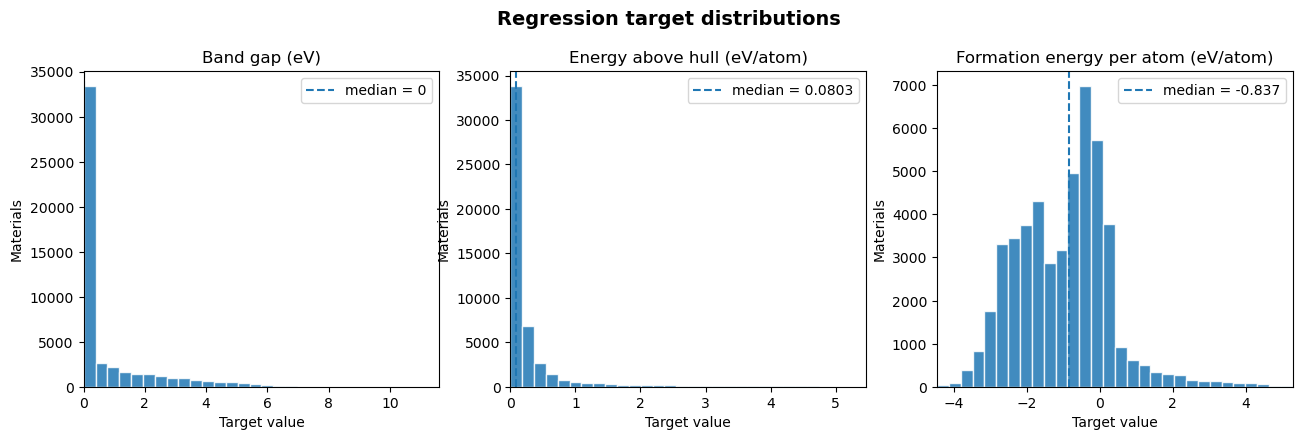

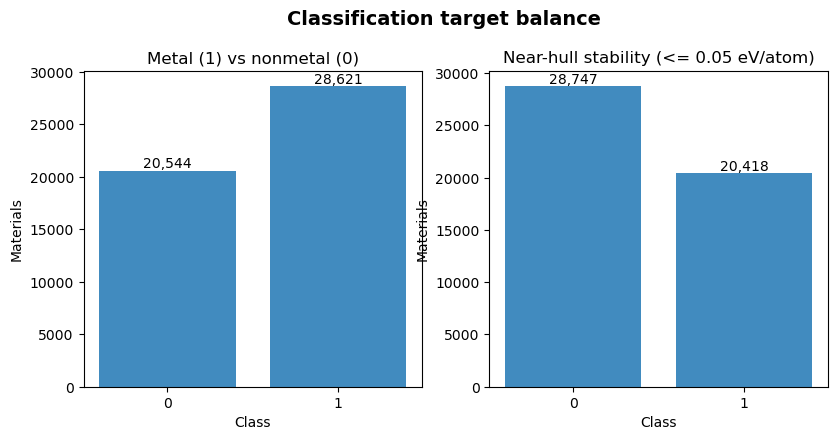

In [11]:
available_regression = target_registry.query("task == 'regression'")
available_classification = target_registry.query("task == 'classification'")

if len(available_regression):
    fig, axes = plt.subplots(1, len(available_regression), figsize=(5.2 * len(available_regression), 4.1), squeeze=False)
    for ax, (_, spec) in zip(axes.ravel(), available_regression.iterrows()):
        values = pd.to_numeric(df[spec.target], errors='coerce').dropna()
        ax.hist(values, bins= min(30, max(6, int(np.sqrt(len(values))))), edgecolor='white', alpha=0.85)
        ax.axvline(values.median(), linestyle='--', linewidth=1.5, label=f'median = {values.median():.3g}')
        ax.set_title(spec.display_name)
        ax.set_xlim(values.min(), values.max())
        ax.set_xlabel('Target value')
        ax.set_ylabel('Materials')
        ax.legend()
    fig.suptitle('Regression target distributions', y=1.03, fontsize=14, fontweight='bold')
    save_figure(fig, '01_regression_target_distributions.png')
    plt.show()

if len(available_classification):
    fig, axes = plt.subplots(1, len(available_classification), figsize=(4.8 * len(available_classification), 4.1), squeeze=False)
    for ax, (_, spec) in zip(axes.ravel(), available_classification.iterrows()):
        values = pd.to_numeric(df[spec.target], errors='coerce').dropna().astype(int)
        counts = values.value_counts().reindex([0, 1], fill_value=0)
        ax.bar(['0', '1'], counts.values, alpha=0.85)
        for i, value in enumerate(counts.values):
            ax.text(i, value, f'{value:,}', ha='center', va='bottom')
        ax.set_title(spec.display_name)
        ax.set_xlabel('Class')
        ax.set_ylabel('Materials')
    fig.suptitle('Classification target balance', y=1.03, fontsize=14, fontweight='bold')
    save_figure(fig, '02_classification_target_balance.png')
    plt.show()

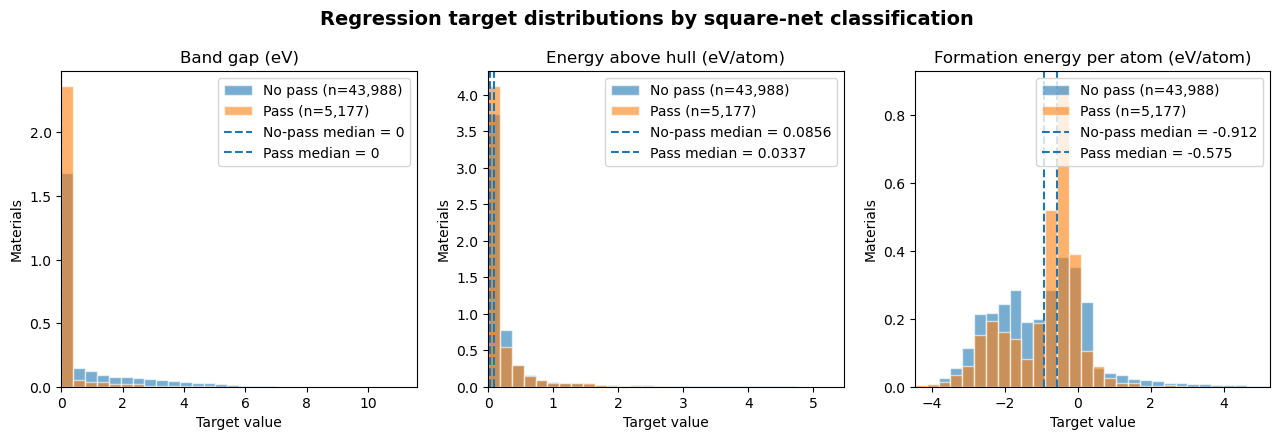

In [12]:
available_regression = target_registry.query("task == 'regression'")
available_classification = target_registry.query("task == 'classification'")


fig, axes = plt.subplots(
    1,
    len(available_regression),
    figsize=(5.2 * len(available_regression), 4.1),
    squeeze=False,
)

for ax, (_, spec) in zip(axes.ravel(), available_regression.iterrows()):

    # Keep target and classification columns together
    plot_df = df[[spec.target, "has_any_pass"]].copy()
    plot_df[spec.target] = pd.to_numeric(
        plot_df[spec.target],
        errors="coerce",
    )
    plot_df = plot_df.dropna(subset=[spec.target, "has_any_pass"])

    # Split by square-net pass classification
    not_passing = plot_df.loc[plot_df["has_any_pass"] == 0, spec.target]
    passing = plot_df.loc[plot_df["has_any_pass"] == 1, spec.target]

    # Use the full target distribution to define common bins
    values = plot_df[spec.target]
    n_bins = min(30, max(6, int(np.sqrt(len(values)))))
    bins = np.linspace(values.min(),values.max(),n_bins + 1,)

    # Overlay the two distributions
    ax.hist(
        not_passing,
        bins=bins,
        density = True,
        alpha=0.6,
        edgecolor="white",
        label=f"No pass (n={len(not_passing):,})",
    )

    ax.hist(
        passing,
        bins=bins,
        density = True,
        alpha=0.6,
        edgecolor="white",
        label=f"Pass (n={len(passing):,})",
    )

    # Optional median lines for each group
    if len(not_passing):
        ax.axvline(
            not_passing.median(),
            linestyle="--",
            linewidth=1.5,
            label=f"No-pass median = {not_passing.median():.3g}",
        )

    if len(passing):
        ax.axvline(
            passing.median(),
            linestyle="--",
            linewidth=1.5,
            label=f"Pass median = {passing.median():.3g}",
        )

    ax.set_title(spec.display_name)
    ax.set_xlim(values.min(), values.max())
    ax.set_xlabel("Target value")
    ax.set_ylabel("Materials")
    ax.legend()

fig.suptitle(
    "Regression target distributions by square-net classification",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

save_figure(
    fig,
    "01_regression_target_distributions_by_pass.png",
)

plt.show()

,target_name,pass,count,mean,median,std
0,Band gap (eV),0,43988,0.815987,0.0,1.407878
1,Band gap (eV),1,5177,0.154272,0.0,0.617458
2,Energy above hull (eV/atom),0,43988,0.292941,0.085624,0.634229
3,Energy above hull (eV/atom),1,5177,0.18188,0.033654,0.369642
4,Formation energy per atom (eV/atom),0,43988,-1.009204,-0.912081,1.316432
5,Formation energy per atom (eV/atom),1,5177,-0.897527,-0.574615,1.002668
6,Metal (1) vs nonmetal (0),0,43988,0.546649,1.0,0.497825
7,Metal (1) vs nonmetal (0),1,5177,0.883716,1.0,0.320596
8,Near-hull stability (<= 0.05 eV/atom),0,43988,0.398768,0.0,0.48965
9,Near-hull stability (<= 0.05 eV/atom),1,5177,0.555727,1.0,0.496933


C:\Users\mscoo\AppData\Local\Temp\ipykernel_36728\3928967950.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['No pass', 'Any pass'], showfliers=True)
C:\Users\mscoo\AppData\Local\Temp\ipykernel_36728\3928967950.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['No pass', 'Any pass'], showfliers=True)
C:\Users\mscoo\AppData\Local\Temp\ipykernel_36728\3928967950.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['No pass', 'Any pass'], showfliers=True)


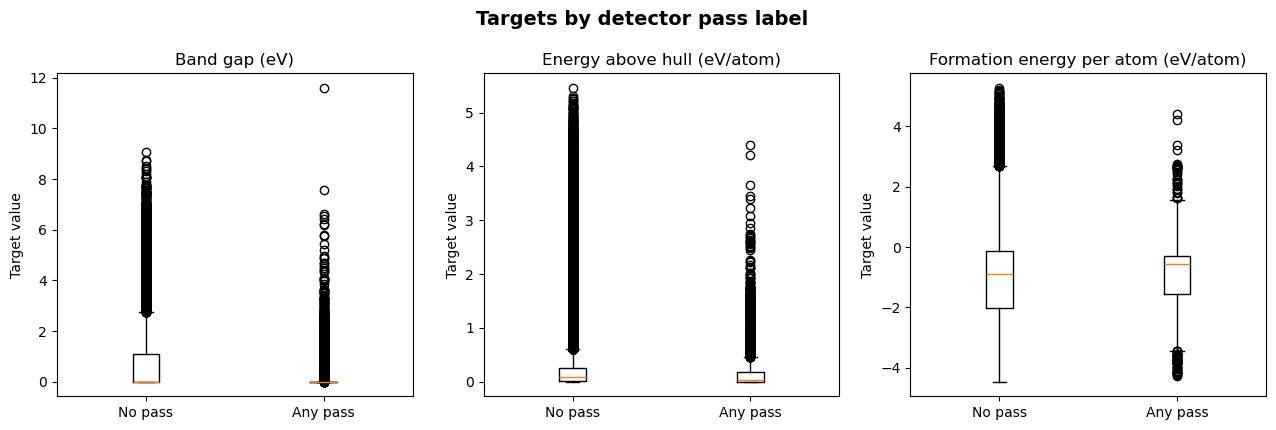

In [13]:
if 'has_any_pass' in df.columns:
    pass_flag = pd.to_numeric(df['has_any_pass'], errors='coerce').fillna(0).astype(int)
    summaries = []
    for _, spec in target_registry.iterrows():
        temp = pd.DataFrame({'pass': pass_flag, 'target': pd.to_numeric(df[spec.target], errors='coerce')}).dropna()
        grouped = temp.groupby('pass')['target'].agg(['count','mean','median','std']).reset_index()
        grouped.insert(0, 'target_name', spec.display_name)
        summaries.append(grouped)
    detector_target_summary = pd.concat(summaries, ignore_index=True) if summaries else pd.DataFrame()
    display(detector_target_summary)

    if len(available_regression):
        fig, axes = plt.subplots(1, len(available_regression), figsize=(5.2 * len(available_regression), 4.2), squeeze=False)
        for ax, (_, spec) in zip(axes.ravel(), available_regression.iterrows()):
            plot_data = pd.DataFrame({
                'has_any_pass': pass_flag,
                'target': pd.to_numeric(df[spec.target], errors='coerce'),
            }).dropna()
            groups = [plot_data.loc[plot_data.has_any_pass == value, 'target'] for value in [0, 1]]
            ax.boxplot(groups, labels=['No pass', 'Any pass'], showfliers=True)
            ax.set_title(spec.display_name)
            ax.set_ylabel('Target value')
        fig.suptitle('Targets by detector pass label', y=1.03, fontsize=14, fontweight='bold')
        save_figure(fig, '03_targets_by_detector_pass.png')
        plt.show()
else:
    display(Markdown('> `has_any_pass` is absent, so detector-label EDA and that feature extension will be limited.'))


In [15]:
df.head()


,material_id,formula,n_layers_total,n_axes,n_species,n_pass,pass_fraction_total,has_any_pass,dominant_has_pass,dominant_axis,dominant_species,dominant_plane_id,dominant_plane_center_frac,dominant_passes2_fail_reasons,dominant_mean_score,dominant_tol_ratio_any,dominant_nn_intra_min,dominant_min_adj_dist_any_atom,dominant_uv_ang_deg_mean,dominant_uv_ang_err_mean,dominant_uv_len_err_mean,dominant_cnn_in_plane_bond_angle_deg_mean,dominant_cnn_out_of_plane_tilt_angle_deg_mean,dominant_coplane_species_counts_json,dominant_coplane_n_species,dominant_coplane_major_species,dominant_coplane_major_fraction,dominant_coplane_other_species_counts_json,dominant_coplane_other_n_species,dominant_coplane_other_fraction,dominant_cnn_out_of_plane_nn_species,dominant_cnn_out_of_plane_nn_dist,dominant_cnn_out_of_plane_bonded_species_counts_json,dominant_cnn_out_of_plane_bonded_major_species,dominant_cnn_out_of_plane_bonded_major_fraction,dominant_cnn_out_of_plane_bonded_n_species,dominant_square_species_oxi_state_mean,dominant_square_species_oxi_state_std,dominant_has_out_of_plane_same_species_bond,dominant_adj_atom_plane_major_species,dominant_adj_atom_plane_major_fraction,dominant_adj_atom_plane_species_counts_json,dominant_adj_plane_plane_major_species,dominant_adj_plane_plane_major_fraction,dominant_adj_plane_plane_species_counts_json,sg_number,sg_symbol,crystal_system,formula_pretty,mp__band_gap_ev,...,comp__atomic_mass__std,comp__atomic_mass__min,comp__atomic_mass__max,comp__atomic_mass__range,comp__electronegativity__mean,comp__electronegativity__std,comp__electronegativity__min,comp__electronegativity__max,comp__electronegativity__range,comp__row__mean,comp__row__std,comp__row__min,comp__row__max,comp__row__range,comp__group__mean,comp__group__std,comp__group__min,comp__group__max,comp__group__range,comp__atomic_radius__mean,comp__atomic_radius__std,comp__atomic_radius__min,comp__atomic_radius__max,comp__atomic_radius__range,cv_group,chemjson__dominant_coplane_species__total,chemjson__dominant_coplane_species__richness,chemjson__dominant_coplane_species__entropy,chemjson__dominant_coplane_species__concentration,chemjson__dominant_coplane_species__max_fraction,chemjson__dominant_coplane_other_species__total,chemjson__dominant_coplane_other_species__richness,chemjson__dominant_coplane_other_species__entropy,chemjson__dominant_coplane_other_species__concentration,chemjson__dominant_coplane_other_species__max_fraction,chemjson__dominant_cnn_out_of_plane_bonded_species__total,chemjson__dominant_cnn_out_of_plane_bonded_species__richness,chemjson__dominant_cnn_out_of_plane_bonded_species__entropy,chemjson__dominant_cnn_out_of_plane_bonded_species__concentration,chemjson__dominant_cnn_out_of_plane_bonded_species__max_fraction,chemjson__dominant_adj_atom_plane_species__total,chemjson__dominant_adj_atom_plane_species__richness,chemjson__dominant_adj_atom_plane_species__entropy,chemjson__dominant_adj_atom_plane_species__concentration,chemjson__dominant_adj_atom_plane_species__max_fraction,chemjson__dominant_adj_plane_plane_species__total,chemjson__dominant_adj_plane_plane_species__richness,chemjson__dominant_adj_plane_plane_species__entropy,chemjson__dominant_adj_plane_plane_species__concentration,chemjson__dominant_adj_plane_plane_species__max_fraction
0,mp-1103821,Cu5Sn2Te7,52.0,3.0,3.0,0.0,0.000000,0.0,0.0,b,Cu,1.0,0.265988,primary_pass_failed,1.984846e-01,1.676686,4.289915,2.558568,89.880927,4.727615e-01,8.547092e-03,NaN,35.463778,"{""Cu"": 5}",1.0,Cu,1.00,{},0.0,NaN,Te,2.558568,"{""Te"": 20}",Te,1.0,1.0,1.2,0.4,0.0,Te,1.0,"{""Te"": 4}",Sn,1.0,"{""Sn"": 2}",5.0,C2,Monoclinic,Cu5Sn2Te7,0.0000,...,29.892592,63.5460,127.60000,64.05400,2.008571,0.093416,1.90,2.10,0.20,4.642857,0.479157,4.0,5.0,1.0,13.928571,2.282364,11.0,16.0,5.0,1.340000,0.110000,1.23,1.45,0.22,formula::Cu5Sn2Te7,5.0,1.0,0.000000,1.000,1.00,0.0,0.0,0.0,0.0,NaN,20.0,1.0,0.0,1.0,1.0,4.0,1.0,0.000000,1.00,1.0,2.0,1.0,0.000000,1.00,1.0
1,mp-571641,PrCdPd,22.0,3.0,3.0,0.0,0.000000,0.0,0.0

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Binned relationship: dominant_tol_ratio_any vs target_is_metal'}, xlabel='dominant_tol_ratio_any', ylabel='target_is_metal'>)

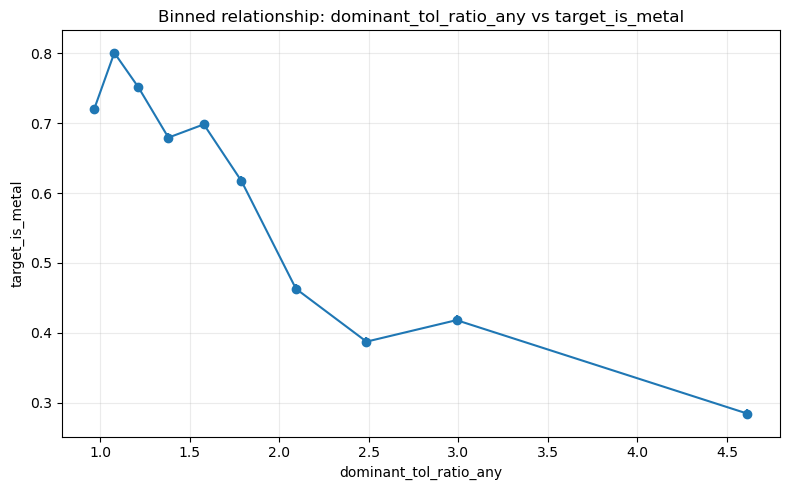

In [16]:
plot_binned_target(
    df,
    feature="dominant_tol_ratio_any",
    target="target_is_metal",
)


Tolerance ratio is a geometric parameter extracted from the square-net detection algorithm which is a ratio of the out-of-plane nearest neighbor distance, to the in-plane nearest neighbor distance. We can see that a tolerance ratio close to one means the material is more likely to be metallic, showing the promise of the detection parameters in adding predictive information. 

## 6. Define feature families

Feature assignment is explicit and pattern-audited. The notebook excludes identifiers, formulas, CV groups, raw JSON dictionaries, detector failure-reason text, canonical targets, direct target fields, and fields used to derive proxy targets.

- **Baseline:** composition descriptors plus space group, crystal system, lattice metrics, density/volume/site-count fields when available.
- **Detector label:** `has_any_pass`, dominant pass state, dominant axis, and dominant species.
- **Layer geometry:** square scores, tolerance ratios, in-plane distances, angle/length errors, and layer/adjacent-plane separations.
- **Layer chemistry:** co-plane and adjacent-plane summaries, oxidation states, CrystalNN bonding/species/angle summaries, and compact JSON-count diversity summaries.


In [17]:
canonical_target_columns = set(target_registry['target'])
all_target_like_columns = {
    c for c in df.columns
    if c in canonical_target_columns
    #or c in target_source_columns
    or c.lower().startswith('target_')
    or c.lower().startswith('target__')
}
identifier_columns = {
    ID_COLUMN, FORMULA_COLUMN, 'cv_group', CONFIG.grouping_col,
    'reduced_formula_derived', 'chemical_system_derived',
}
raw_unstable_columns = {
    c for c in df.columns
    if c.lower().endswith('counts_json')
    or 'fail_reason' in c.lower()
    or c.lower().endswith('_json')
}
EXCLUDED_COLUMNS = all_target_like_columns | identifier_columns | raw_unstable_columns

global_columns = ['sg_number', 'sg_symbol', 'crystal_system']

composition_columns = [c for c in df.columns if c.startswith('comp__')]

detector_columns = ['has_any_pass', 'dominant_has_pass', 'dominant_axis', 'dominant_species']

geometry_columns = [
    'dominant_mean_score', 'dominant_tol_ratio_any', 'dominant_nn_intra_min', 
    'dominant_min_adj_dist_any_atom', 'dominant_uv_ang_deg_mean', 'dominant_uv_ang_err_mean', 'dominant_uv_len_err_mean'
]

chemistry_patterns = [
    r'coplane', r'adj_atom_plane', r'adj_plane_plane', r'oxid', r'oxi_', r'cnn_', r'crystalnn',
    r'bonded', r'bond_angle', r'tilt_angle', r'out_of_plane_same_species', r'^chemjson__',
]

chemistry_columns = columns_matching(list(df.columns), chemistry_patterns)

families = {
    'composition': ordered_unique([c for c in composition_columns if c not in EXCLUDED_COLUMNS]),
    'global crystal': ordered_unique([c for c in global_columns if c not in EXCLUDED_COLUMNS]),
    'detector label': ordered_unique([c for c in detector_columns if c not in EXCLUDED_COLUMNS]),
    'layer geometry': ordered_unique([c for c in geometry_columns if c not in EXCLUDED_COLUMNS]),
    'layer chemistry': ordered_unique([c for c in chemistry_columns if c not in EXCLUDED_COLUMNS]),
}

baseline_columns = ordered_unique(families['composition'] + families['global crystal'])

FEATURE_SETS = {
    'Baseline': baseline_columns,
    'Baseline + detector label': ordered_unique(baseline_columns + families['detector label']),
    'Baseline + layer geometry': ordered_unique(baseline_columns + families['layer geometry']),
    'Baseline + layer chemistry': ordered_unique(baseline_columns + families['layer chemistry']),
    'Combined': ordered_unique(
        baseline_columns + families['detector label'] + families['layer geometry'] + families['layer chemistry']
    ),
}
FEATURE_SET_ORDER = list(FEATURE_SETS)

family_rows = []
for family_name, columns in families.items():
    numeric = [c for c in columns if pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c])]
    categorical = [c for c in columns if c not in numeric]
    family_rows.append({
        'family': family_name,
        'n_columns': len(columns),
        'n_numeric': len(numeric),
        'n_categorical': len(categorical),
        'median_missing_fraction': float(df[columns].isna().mean().median()) if columns else np.nan,
        'example_columns': ', '.join(columns[:7]),
    })
    
family_manifest = pd.DataFrame(family_rows)

set_manifest = pd.DataFrame([
    {
        'feature_set': name,
        'n_raw_columns': len(columns),
        'n_numeric': sum(pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c]) for c in columns),
        'n_categorical': sum(not (pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c])) for c in columns),
    }
    for name, columns in FEATURE_SETS.items()
])

display(family_manifest)
display(set_manifest)

,family,n_columns,n_numeric,n_categorical,median_missing_fraction,example_columns
0,composition,42,42,0,0.000061,"comp__n_elements, comp__total_atoms_formula, comp__stoich_entropy, comp__max_element_fraction, comp__min_element_fra..."
1,global crystal,3,1,2,0.000000,"sg_number, sg_symbol, crystal_system"
2,detector label,4,2,2,0.000000,"has_any_pass, dominant_has_pass, dominant_axis, dominant_species"
3,layer geometry,7,7,0,0.000000,"dominant_mean_score, dominant_tol_ratio_any, dominant_nn_intra_min, dominant_min_adj_dist_any_atom, dominant_uv_ang_..."
4,layer chemistry,44,39,5,0.000000,"dominant_cnn_in_plane_bond_angle_deg_mean, dominant_cnn_out_of_plane_tilt_angle_deg_mean, dominant_coplane_n_species..."


,feature_set,n_raw_columns,n_numeric,n_categorical
0,Baseline,45,43,2
1,Baseline + detector label,49,45,4
2,Baseline + layer geometry,52,50,2
3,Baseline + layer chemistry,89,82,7
4,Combined,100,91,9



# Experimental protocol

### Fair-comparison controls

- The target-specific cohort is selected **once** using target availability only; rows are not dropped because a feature is missing.
- Grouped splits are generated **once per target** and then reused for every feature set.
- Numeric preprocessing is median imputation plus missing indicators and standardization.
- Categorical preprocessing is most-frequent imputation plus fold-local one-hot encoding with unknown-category handling.
- The model specification and regularization are fixed before seeing feature-set results.
- Every target-like/source column is excluded from all predictors.

### Why a regularized linear probe?

Ridge and logistic regression are deliberately used as controlled information probes. They are fast enough for repeated grouped CV, support identical mixed-type preprocessing, and minimize the risk that hyperparameter search or different nonlinear interactions masquerade as descriptor value. A later robustness notebook can repeat the same frozen splits with a nonlinear estimator.

### Metrics

- Regression: MAE (primary), RMSE, and R-squared.
- Classification: ROC AUC (primary when defined), average precision, balanced accuracy, and F1.
- Paired differences are re-oriented so **positive always means the candidate feature set is better**.

### Implementation boundary

The split generation, fold-local preprocessing, fixed Ridge/logistic models, prediction collection, and failure logging are implemented in `experiment_protocol.py`. The notebook retains the protocol rationale and the resulting diagnostics so the experimental choices remain reviewable.


In [18]:
fold_scores, fold_predictions, split_manifest, failures, splits = evaluate_feature_sets(
    data=df,
    target_registry=target_registry,
    feature_sets=FEATURE_SETS,
    config=CONFIG,
    model_names = ["linear"],
)

print(f'\nCompleted score rows: {len(fold_scores):,}')
print(f'Completed prediction rows: {len(fold_predictions):,}')
if len(failures):
    display(Markdown(f'> **Evaluation warnings:** {len(failures)} fit or split operations failed.'))
    display(failures.head(20))
else:
    print('No split or model failures recorded.')




Band gap (eV): building shared grouped splits...
  15 paired splits (3 repeats x 5 folds)
  feature set: Baseline (45 raw columns)
    model: linear
  feature set: Baseline + detector label (49 raw columns)
    model: linear
  feature set: Baseline + layer geometry (52 raw columns)
    model: linear
  feature set: Baseline + layer chemistry (89 raw columns)
    model: linear
  feature set: Combined (100 raw columns)
    model: linear

Energy above hull (eV/atom): building shared grouped splits...
  15 paired splits (3 repeats x 5 folds)
  feature set: Baseline (45 raw columns)
    model: linear
  feature set: Baseline + detector label (49 raw columns)
    model: linear
  feature set: Baseline + layer geometry (52 raw columns)
    model: linear
  feature set: Baseline + layer chemistry (89 raw columns)
    model: linear
  feature set: Combined (100 raw columns)
    model: linear

Formation energy per atom (eV/atom): building shared grouped splits...
  15 paired splits (3 repeats x 5 fo

In [19]:
import joblib

#export splits for repeat experiments using non-linear model
joblib.dump(splits, OUTPUT_DIR / "grouped_splits_band_gap.pkl")

['C:\\Users\\mscoo\\GIT_projects\\Squarenet_ML\\outputs\\experiment_A\\grouped_splits_band_gap.pkl']

In [20]:
score_summary = summarize_scores(fold_scores, CONFIG)
paired_fold_differences = paired_against_baseline(fold_scores)
paired_summary = summarize_paired(paired_fold_differences, CONFIG)
primary_score_summary, paired_primary = primary_metric_tables(
    score_summary, paired_summary, target_registry
)

primary_score_display = primary_score_summary.copy()
primary_score_display["display_rank"] = np.where(
    primary_score_display.metric.isin(LOWER_IS_BETTER),
    primary_score_display.mean_score,
    -primary_score_display.mean_score,
)
display(primary_score_display.sort_values(["target_name", "display_rank"]).drop(columns="display_rank"))
display(paired_primary.sort_values(["target_name", "mean_improvement"], ascending=[True, False]))

,target,target_name,task,feature_set,model_name,metric,mean_score,repeat_std,ci_low,ci_high,n_repeats,n_fold_scores
4,target_band_gap_ev,Band gap (eV),regression,Combined,linear,mae,0.714024,0.001822,0.712880,0.716125,3,15
2,target_band_gap_ev,Band gap (eV),regression,Baseline + layer chemistry,linear,mae,0.720122,0.002017,0.718888,0.722449,3,15
1,target_band_gap_ev,Band gap (eV),regression,Baseline + detector label,linear,mae,0.729382,0.001576,0.728343,0.731196,3,15
3,target_band_gap_ev,Band gap (eV),regression,Baseline + layer geometry,linear,mae,0.737000,0.001211,0.736160,0.738388,3,15
0,target_band_gap_ev,Band gap (eV),regression,Baseline,linear,mae,0.738983,0.001121,0.738196,0.740267,3,15
5,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline,linear,mae,0.221982,0.000086,0.221914,0.222079,3,15
6,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + detector label,linear,mae,0.222809,0.000140,0.222679,0.222957,3,15
9,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Combined,linear,mae,0.222971,0.000077,0.222903,0.223055,3,15
7,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer chemistry,linear,mae,0.223235,0.000167,0.223091,0.223417,3,15
8,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer geometry,linear,mae,0.225331,0.000064,0.225261,0.225386,3,15


,target,target_name,task,feature_set,model_name,metric,mean_improvement,median_fold_improvement,ci_low,ci_high,fold_win_rate,n_paired_folds,n_repeats,evidence
3,target_band_gap_ev,Band gap (eV),regression,Combined,linear,mae,0.024959,0.024716,0.024142,0.025421,1.000000,15,3,consistent improvement
1,target_band_gap_ev,Band gap (eV),regression,Baseline + layer chemistry,linear,mae,0.018862,0.018022,0.017818,0.019460,1.000000,15,3,consistent improvement
0,target_band_gap_ev,Band gap (eV),regression,Baseline + detector label,linear,mae,0.009601,0.009539,0.009071,0.009880,1.000000,15,3,consistent improvement
2,target_band_gap_ev,Band gap (eV),regression,Baseline + layer geometry,linear,mae,0.001984,0.001746,0.001879,0.002036,1.000000,15,3,consistent improvement
4,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + detector label,linear,mae,-0.000826,-0.001041,-0.000877,-0.000765,0.200000,15,3,consistent degradation
7,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Combined,linear,mae,-0.000989,-0.001157,-0.001141,-0.000876,0.333333,15,3,consistent degradation
5,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer chemistry,linear,mae,-0.001253,-0.001699,-0.001338,-0.001136,0.400000,15,3,consistent degradation
6,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer geometry,linear,mae,-0.003348,-0.003394,-0.003432,-0.003307,0.000000,15,3,consistent degradation
11,target_formation_energy_per_atom_ev,Formation energy per atom (eV/atom),regression,Combined,linear,mae,0.044814,0.045096,0.044450,0.045091,1.000000,15,3,consistent improvement
9,target_formation_energy_per_atom_ev,Formation energy per atom (eV/atom),regression,Baseline + layer chemistry,linear,mae,0.036362,0.035959,0.036144,0.036595,1.000000,15,3,consistent improvement


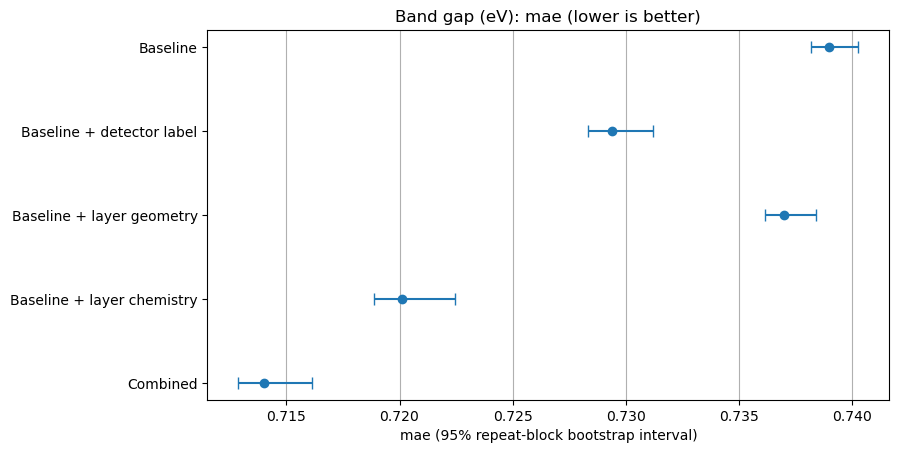

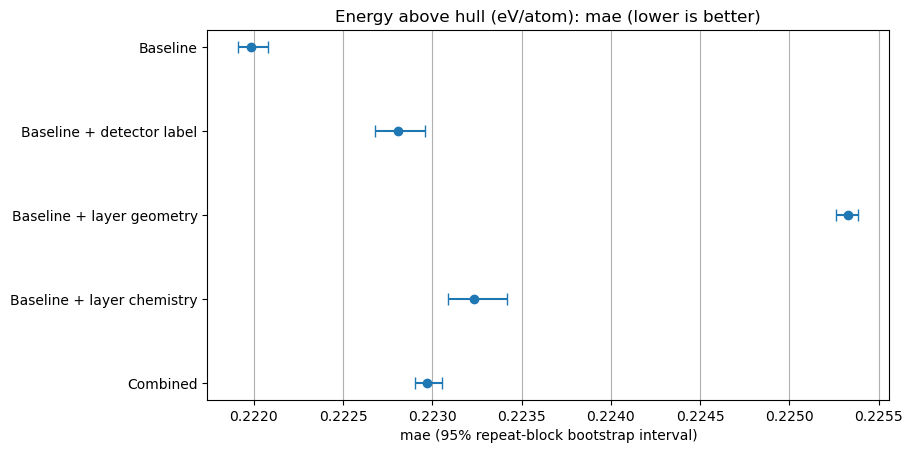

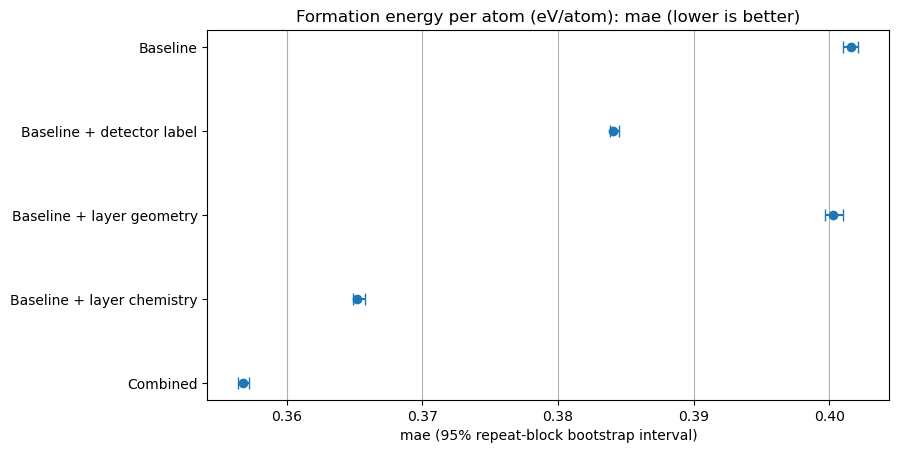

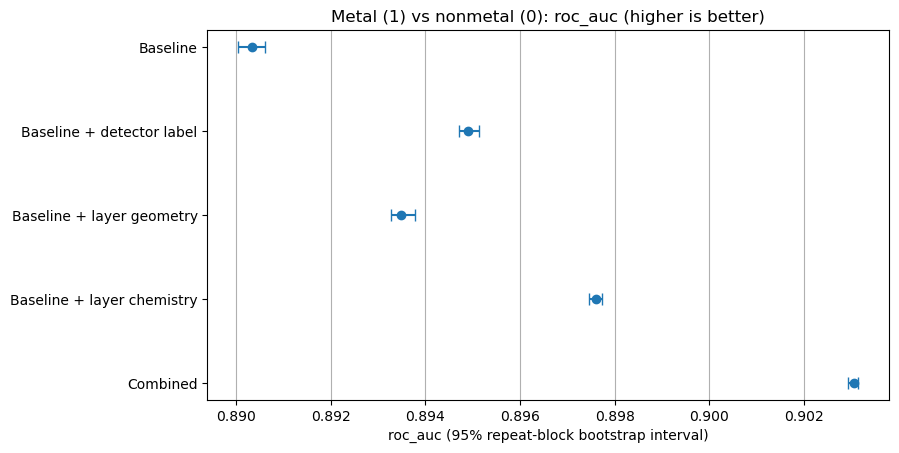

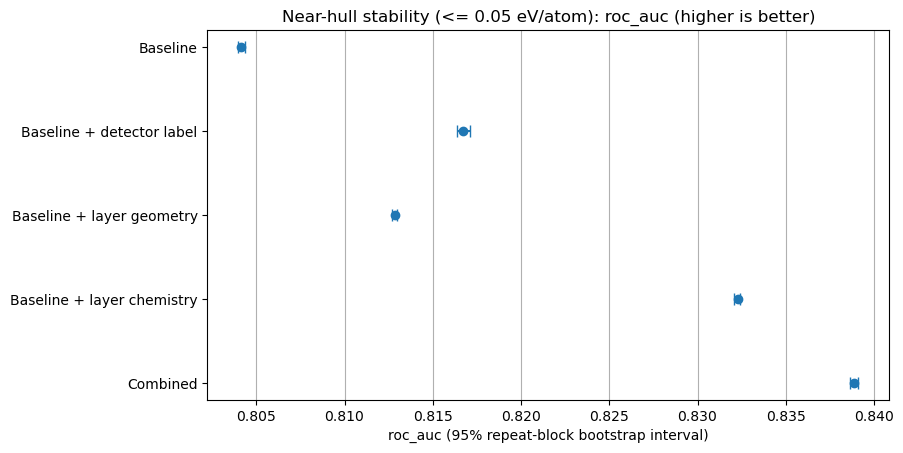

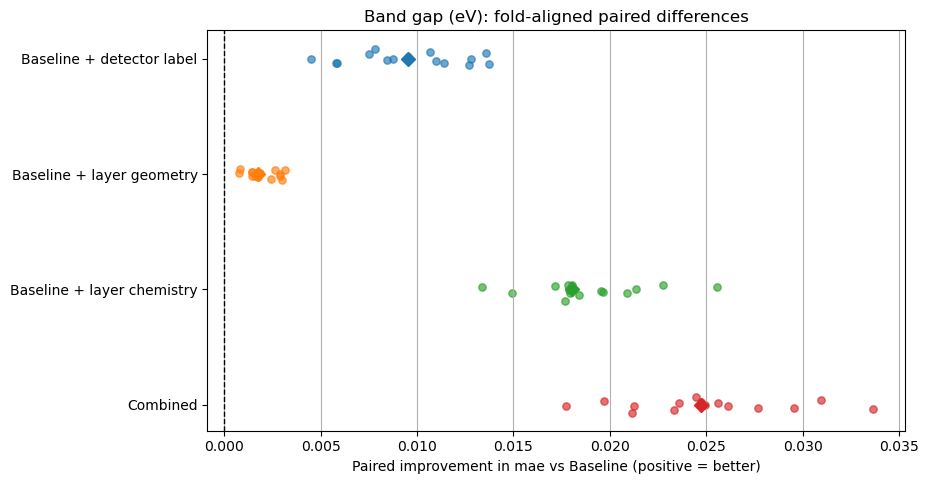

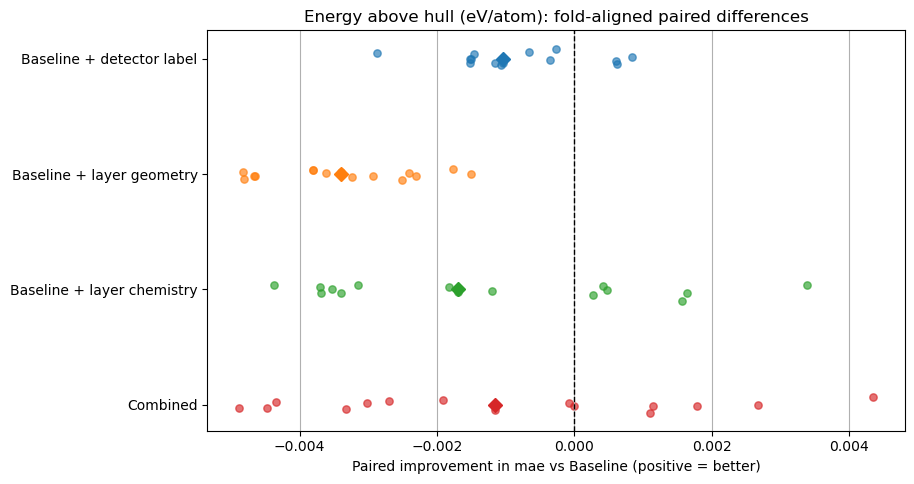

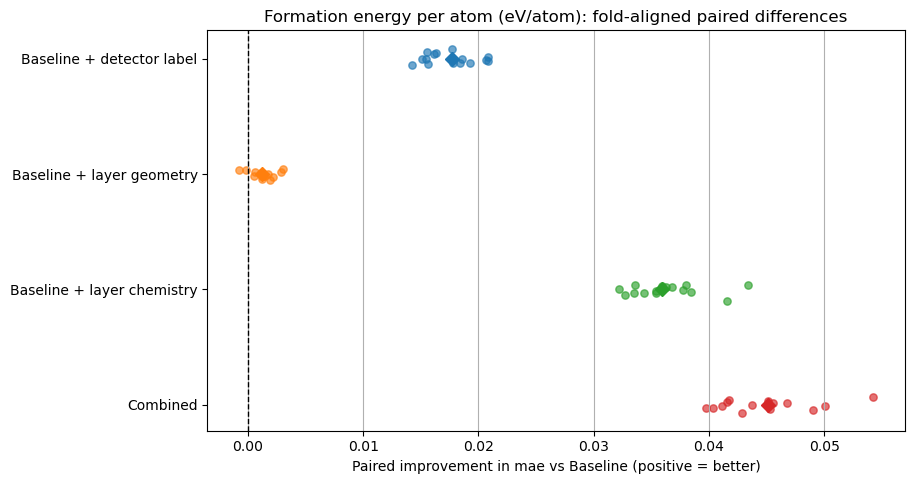

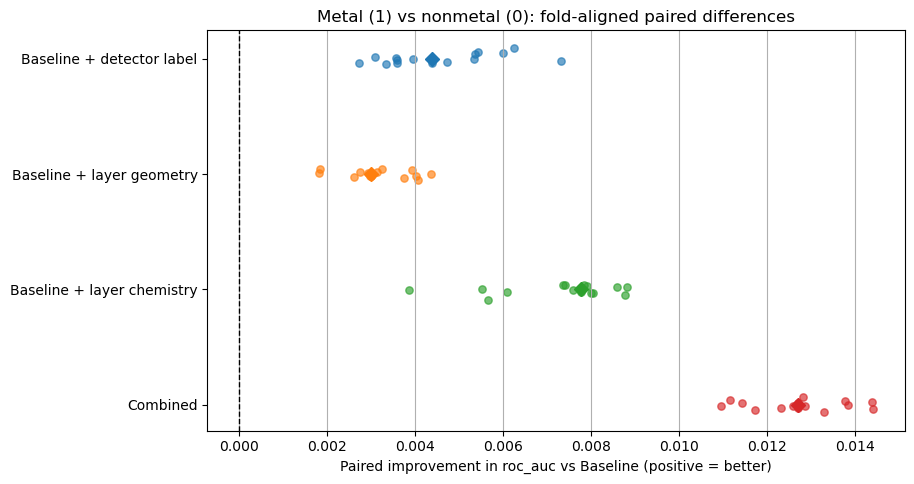

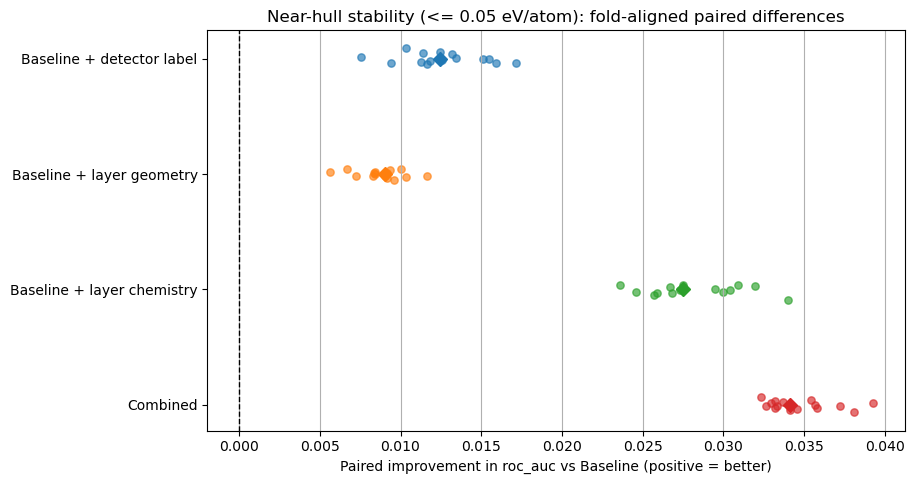

In [21]:
# Primary metric score plots
for target, group in primary_score_summary.groupby('target', sort=False):
    group = group.set_index('feature_set').reindex(FEATURE_SET_ORDER).dropna(subset=['mean_score']).reset_index()
    if group.empty:
        continue
    task = group.task.iloc[0]
    metric = group.metric.iloc[0]
    fig, ax = plt.subplots(figsize=(8.8, 4.8))
    y = np.arange(len(group))
    lower = group.mean_score - group.ci_low
    upper = group.ci_high - group.mean_score
    ax.errorbar(group.mean_score, y, xerr=[lower, upper], fmt='o', capsize=4)
    ax.set_yticks(y, labels=group.feature_set)
    ax.invert_yaxis()
    ax.set_xlabel(f'{metric} (95% repeat-block bootstrap interval)')
    direction = 'lower is better' if metric in LOWER_IS_BETTER else 'higher is better'
    ax.set_title(f'{group.target_name.iloc[0]}: {metric} ({direction})')
    ax.grid(axis='x')
    save_figure(fig, f'06_score_{target}.png')
    plt.show()

# Paired fold improvement plots
for target, group in paired_fold_differences.groupby('target', sort=False):
    task = group.task.iloc[0]
    metric = PRIMARY_METRIC[task]
    plot_data = group[group.metric == metric].copy()
    if plot_data.empty and task == 'classification':
        metric = 'balanced_accuracy'
        plot_data = group[group.metric == metric].copy()
    if plot_data.empty:
        continue
    candidates = [name for name in FEATURE_SET_ORDER if name != 'Baseline' and name in set(plot_data.feature_set)]
    fig, ax = plt.subplots(figsize=(9.0, 5.2))
    rng = np.random.default_rng(CONFIG.random_state)
    for position, name in enumerate(candidates):
        values = plot_data.loc[plot_data.feature_set == name, 'improvement'].dropna().to_numpy()
        jitter = rng.normal(0, 0.045, size=len(values))
        ax.scatter(values, np.full(len(values), position) + jitter, s=28, alpha=0.65)
        if len(values):
            ax.plot([np.median(values)], [position], marker='D', markersize=7)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(range(len(candidates)), labels=candidates)
    ax.invert_yaxis()
    ax.set_xlabel(f'Paired improvement in {metric} vs Baseline (positive = better)')
    ax.set_title(f'{plot_data.target_name.iloc[0]}: fold-aligned paired differences')
    ax.grid(axis='x')
    save_figure(fig, f'07_paired_delta_{target}.png')
    plt.show()


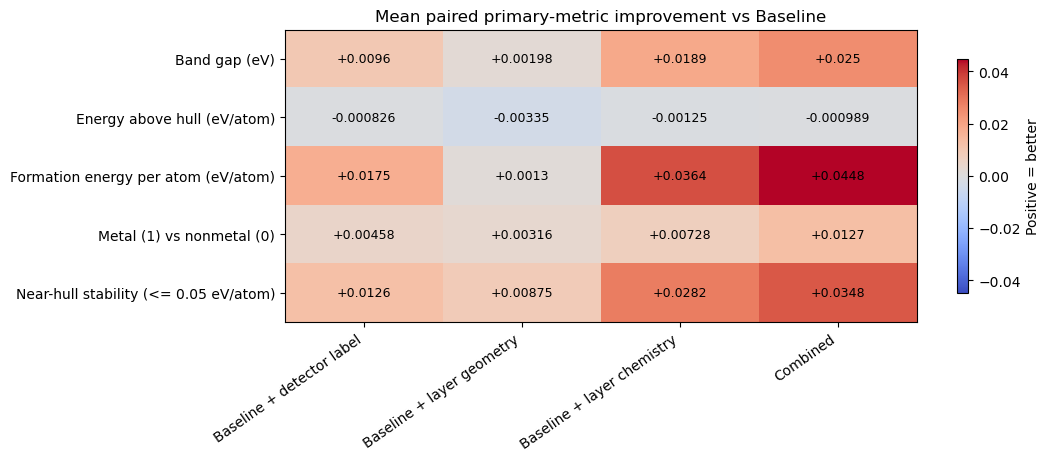

In [22]:

# Cross-target improvement matrix for the primary metric
if not paired_primary.empty:
    matrix = paired_primary.pivot(index='target_name', columns='feature_set', values='mean_improvement')
    matrix = matrix.reindex(columns=[name for name in FEATURE_SET_ORDER if name != 'Baseline'])
    fig, ax = plt.subplots(figsize=(10.2, max(3.8, 0.7 * len(matrix))))
    finite = matrix.to_numpy(dtype=float)
    limit = np.nanmax(np.abs(finite)) if np.isfinite(finite).any() else 1.0
    limit = max(limit, 1e-12)
    image = ax.imshow(matrix, cmap='coolwarm', vmin=-limit, vmax=limit, aspect='auto')
    ax.set_xticks(range(len(matrix.columns)), labels=matrix.columns, rotation=35, ha='right')
    ax.set_yticks(range(len(matrix.index)), labels=matrix.index)
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix.iloc[row, column]
            if pd.notna(value):
                ax.text(column, row, f'{value:+.3g}', ha='center', va='center', fontsize=9)
    ax.set_title('Mean paired primary-metric improvement vs Baseline')
    fig.colorbar(image, ax=ax, shrink=0.8, label='Positive = better')
    save_figure(fig, '08_primary_metric_improvement_matrix.png')
    plt.show()


## 8. Feature reduction: correlated or low-variance features

**Question**: Are there features that add no predicitive signal or are redundant? Could we achieve a similar performance with less features?

Here we will look for highly correlated features that offer redundant information as well as features whose values remain nearly constant. Once identified, we can retrain our models with reduced feature families and compare performance. If performance is not greatly diminished then we will keep the reduced feature list. 



#### Correlation and variance analysis

    - Plot and filter out highly correlated features based upon chosen threshold (0.95)
    - Filter out columns that are near constant 
    - Create a new dataset with reduced features that can be compared with the full dataset

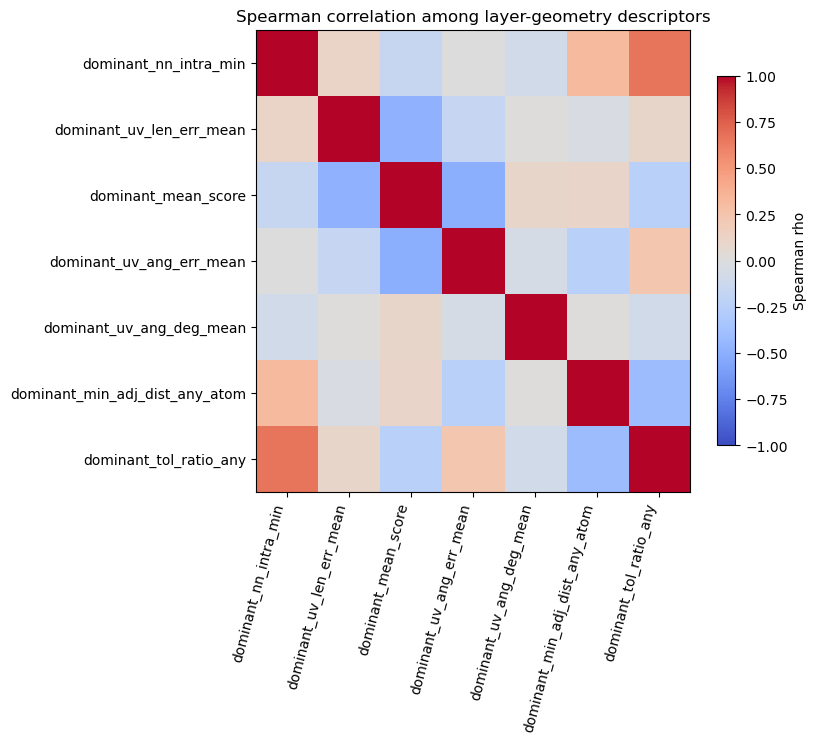

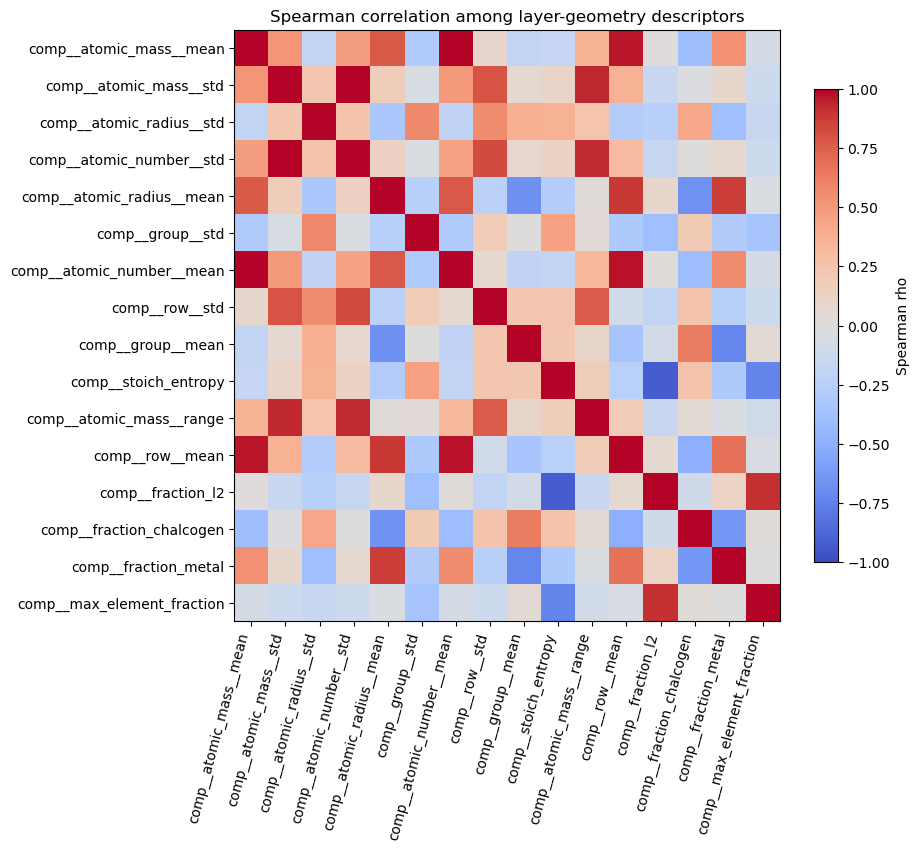

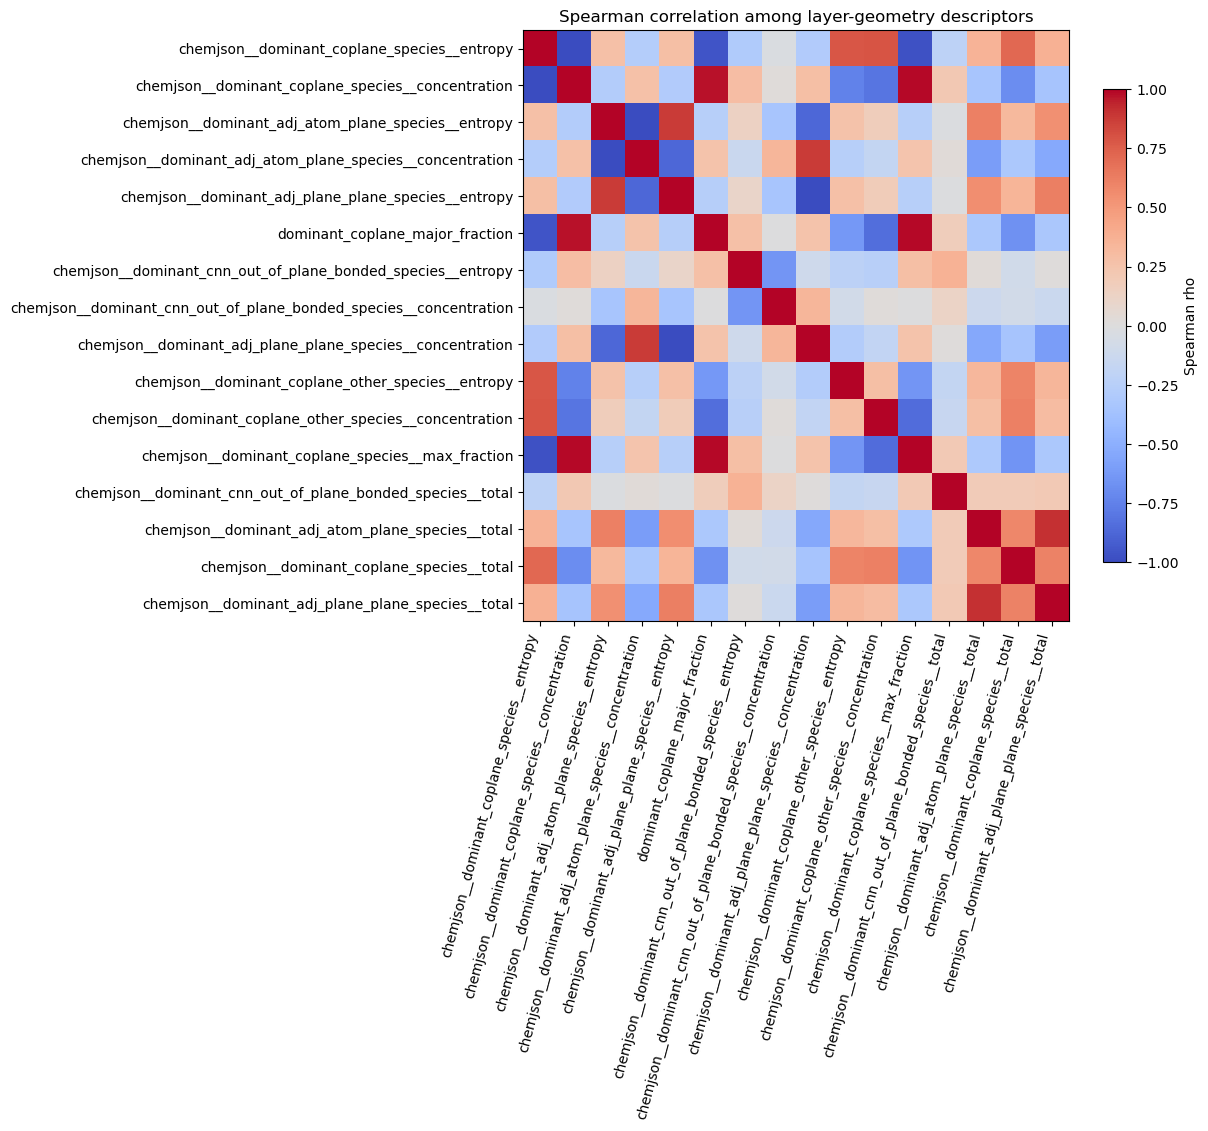

In [23]:
# Correlation structure among the most complete geometry features
geometry_numeric = [
    c for c in families['layer geometry']
    if pd.api.types.is_numeric_dtype(df[c]) and df[c].notna().sum() >= max(5, int(0.25 * len(df)))
]
if len(geometry_numeric) >= 2:
    ranked = sorted(geometry_numeric, key=lambda c: (df[c].isna().mean(), -df[c].nunique(dropna=True)))[:16]
    corr = df[ranked].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(max(7, 0.55 * len(ranked)), max(6, 0.48 * len(ranked))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    ax.set_xticks(range(len(ranked)), labels=ranked, rotation=75, ha='right')
    ax.set_yticks(range(len(ranked)), labels=ranked)
    ax.set_title('Spearman correlation among layer-geometry descriptors')
    fig.colorbar(image, ax=ax, shrink=0.8, label='Spearman rho')
    save_figure(fig, '05_geometry_correlation.png')
    plt.show()
else:
    display(Markdown('> Fewer than two sufficiently complete numeric geometry features are available for a correlation audit.'))

geometry_numeric = [
    c for c in families['composition']
    if pd.api.types.is_numeric_dtype(df[c]) and df[c].notna().sum() >= max(5, int(0.25 * len(df)))
]
if len(geometry_numeric) >= 2:
    ranked = sorted(geometry_numeric, key=lambda c: (df[c].isna().mean(), -df[c].nunique(dropna=True)))[:16]
    corr = df[ranked].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(max(7, 0.55 * len(ranked)), max(6, 0.48 * len(ranked))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    ax.set_xticks(range(len(ranked)), labels=ranked, rotation=75, ha='right')
    ax.set_yticks(range(len(ranked)), labels=ranked)
    ax.set_title('Spearman correlation among layer-geometry descriptors')
    fig.colorbar(image, ax=ax, shrink=0.8, label='Spearman rho')
    save_figure(fig, '05_geometry_correlation.png')
    plt.show()
else:
    display(Markdown('> Fewer than two sufficiently complete numeric geometry features are available for a correlation audit.'))

geometry_numeric = [
    c for c in families['layer chemistry']
    if pd.api.types.is_numeric_dtype(df[c]) and df[c].notna().sum() >= max(5, int(0.25 * len(df)))
]
if len(geometry_numeric) >= 2:
    ranked = sorted(geometry_numeric, key=lambda c: (df[c].isna().mean(), -df[c].nunique(dropna=True)))[:16]
    corr = df[ranked].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(max(7, 0.55 * len(ranked)), max(6, 0.48 * len(ranked))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    ax.set_xticks(range(len(ranked)), labels=ranked, rotation=75, ha='right')
    ax.set_yticks(range(len(ranked)), labels=ranked)
    ax.set_title('Spearman correlation among layer-geometry descriptors')
    fig.colorbar(image, ax=ax, shrink=0.8, label='Spearman rho')
    save_figure(fig, '05_geometry_correlation.png')
    plt.show()
else:
    display(Markdown('> Fewer than two sufficiently complete numeric geometry features are available for a correlation audit.'))

#### Both **layer chemistry** and **layer geometry** families contain a considerable number of correlated or anticorrelated feature sets. 

In [24]:
features_corr = df[FEATURE_SETS['Combined']].corr(method='spearman', numeric_only=True)

CORR_THRESHOLD =0.95

#isolate upper triangle of correlation matrix
upper = features_corr.where(
    np.triu(np.ones(features_corr.shape), k=1).astype(bool)
)

to_drop = [
    col for col in upper.columns
    if (abs(upper[col]) > CORR_THRESHOLD).any()
    ]

print('Highly correlated columns:')
print(*to_drop,sep="\n")

Highly correlated columns:
comp__atomic_mass__mean
comp__atomic_mass__std
comp__atomic_mass__min
comp__atomic_mass__max
comp__atomic_mass__range
comp__row__mean
dominant_has_pass
dominant_coplane_other_n_species
chemjson__dominant_coplane_species__richness
chemjson__dominant_coplane_species__entropy
chemjson__dominant_coplane_species__concentration
chemjson__dominant_coplane_species__max_fraction
chemjson__dominant_coplane_other_species__total
chemjson__dominant_coplane_other_species__richness
chemjson__dominant_coplane_other_species__max_fraction
chemjson__dominant_cnn_out_of_plane_bonded_species__richness
chemjson__dominant_cnn_out_of_plane_bonded_species__max_fraction
chemjson__dominant_adj_atom_plane_species__richness
chemjson__dominant_adj_atom_plane_species__entropy
chemjson__dominant_adj_atom_plane_species__concentration
chemjson__dominant_adj_atom_plane_species__max_fraction
chemjson__dominant_adj_plane_plane_species__richness
chemjson__dominant_adj_plane_plane_species__entropy

In [25]:
#only keep total count, drop rest. 
chemjson_add = [
    "chemjson__dominant_coplane_species__",
    "chemjson__dominant_coplane_other_species__",
    "chemjson__dominant_cnn_out_of_plane_bonded_species__",
    "chemjson__dominant_adj_atom_plane_species__",
    "chemjson__dominant_adj_plane_plane_species__",
]

chem_ident = ['richness', 'entropy', 'concentration', 'max_fraction']

for col in to_drop:
    temp = col.split("__")
    if temp[0] == "chemjson":
        to_drop.remove(col)

to_drop_chem = [col+col2 for col in chemjson_add for col2 in chem_ident]

to_drop.extend(to_drop_chem)

#### Check for low variance features

In [26]:
def find_near_zero_variance(df, dominant_threshold=0.95):
    """
    Flag features that are:
      - constant: only one unique non-null value
      - near-constant: >= dominant_threshold of non-null rows
        have the same value
    """
    results = []

    for col in df.columns:
        s = df[col].dropna()
        n_unique = s.nunique()

        if len(s) == 0:
            dominant_fraction = 1.0
        else:
            dominant_fraction = s.value_counts(normalize=True).iloc[0]

        results.append({
            "feature": col,
            "n_unique": n_unique,
            "dominant_fraction": dominant_fraction,
            "constant": n_unique <= 1,
            "near_zero_variance": dominant_fraction >= dominant_threshold
        })

    return pd.DataFrame(results)

near_zero_variance = find_near_zero_variance(df[FEATURE_SETS['Combined']], dominant_threshold=0.95)

nzv = near_zero_variance.loc[near_zero_variance['near_zero_variance']]

display(nzv)

to_drop.extend(nzv["feature"].to_list())

,feature,n_unique,dominant_fraction,constant,near_zero_variance
11,comp__fraction_actinide,127,0.959522,False,True
69,dominant_square_species_oxi_state_std,8,0.991902,False,True


#### Check for missing features

In [27]:
MISSING_THRESHOLD = 0.5

missing_summary = (
    df[FEATURE_SETS['Combined']]
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "n_missing", "mean": "fraction_missing"})
    .reset_index()
    .rename(columns={"index": "feature"})
)

missing_summary["percent_missing"] = (
    100 * missing_summary["fraction_missing"]
)

missing_summary = missing_summary.sort_values(
    "percent_missing",
    ascending=False
)

drop_missing = missing_summary[missing_summary["fraction_missing"] > MISSING_THRESHOLD]

display(drop_missing)

to_drop.extend(drop_missing["feature"].to_list())

,feature,n_missing,fraction_missing,percent_missing
68,dominant_square_species_oxi_state_mean,36199.0,0.736276,73.627581
69,dominant_square_species_oxi_state_std,36199.0,0.736276,73.627581
56,dominant_cnn_in_plane_bond_angle_deg_mean,31471.0,0.640110,64.010983
62,dominant_coplane_other_fraction,26284.0,0.534608,53.460795
84,chemjson__dominant_coplane_other_species__max_fraction,26284.0,0.534608,53.460795


#### Drop missing features and rebuild feature sets

In [28]:
df_reduced = df.drop(columns=to_drop)

to_drop_set = set(to_drop)

reduced_families = {family: [feature for feature in features if feature not in to_drop_set]
                    for family, features in families.items()}

#rebuild reduced feature sets
baseline_columns = ordered_unique(reduced_families['composition'] + reduced_families['global crystal'])

REDUCED_FEATURE_SETS = {
    'Baseline': baseline_columns,
    'Baseline + detector label': ordered_unique(baseline_columns + reduced_families['detector label']),
    'Baseline + layer geometry': ordered_unique(baseline_columns + reduced_families['layer geometry']),
    'Baseline + layer chemistry': ordered_unique(baseline_columns + reduced_families['layer chemistry']),
    'Combined': ordered_unique(
        baseline_columns + reduced_families['detector label'] + reduced_families['layer geometry'] + reduced_families['layer chemistry']
    ),
}

REDUCED_FEATURE_SET_ORDER = list(REDUCED_FEATURE_SETS)  

In [29]:
family_rows = []
for family_name, columns in reduced_families.items():
    numeric = [c for c in columns if pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c])]
    categorical = [c for c in columns if c not in numeric]
    family_rows.append({
        'family': family_name,
        'n_columns': len(columns),
        'n_numeric': len(numeric),
        'n_categorical': len(categorical),
        'median_missing_fraction': float(df[columns].isna().mean().median()) if columns else np.nan,
        'example_columns': ', '.join(columns[:7]),
    })
reduced_family_manifest = pd.DataFrame(family_rows)

reduced_set_manifest = pd.DataFrame([
    {
        'feature_set': name,
        'n_raw_columns': len(columns),
        'n_numeric': sum(pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c]) for c in columns),
        'n_categorical': sum(not (pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c])) for c in columns),
    }
    for name, columns in REDUCED_FEATURE_SETS.items()
])

display(reduced_family_manifest)
display(reduced_set_manifest)

,family,n_columns,n_numeric,n_categorical,median_missing_fraction,example_columns
0,composition,35,35,0,0.000061,"comp__n_elements, comp__total_atoms_formula, comp__stoich_entropy, comp__max_element_fraction, comp__min_element_fra..."
1,global crystal,3,1,2,0.000000,"sg_number, sg_symbol, crystal_system"
2,detector label,3,1,2,0.000000,"has_any_pass, dominant_axis, dominant_species"
3,layer geometry,7,7,0,0.000000,"dominant_mean_score, dominant_tol_ratio_any, dominant_nn_intra_min, dominant_min_adj_dist_any_atom, dominant_uv_ang_..."
4,layer chemistry,19,14,5,0.000000,"dominant_cnn_out_of_plane_tilt_angle_deg_mean, dominant_coplane_n_species, dominant_coplane_major_species, dominant_..."


,feature_set,n_raw_columns,n_numeric,n_categorical
0,Baseline,38,36,2
1,Baseline + detector label,41,37,4
2,Baseline + layer geometry,45,43,2
3,Baseline + layer chemistry,57,50,7
4,Combined,67,58,9


#### Rerun model training with reduced feature sets

In [30]:
fold_scores_reduced, fold_predictions_reduced, split_manifest_reduced, failures_reduced, splits_reduced = evaluate_feature_sets(
    data=df_reduced,
    target_registry=target_registry,
    feature_sets=REDUCED_FEATURE_SETS,
    config=CONFIG,
    model_names = ["linear"],
)

print(f'\nCompleted score rows: {len(fold_scores_reduced):,}')
print(f'Completed prediction rows: {len(fold_predictions_reduced):,}')
if len(failures):
    display(Markdown(f'> **Evaluation warnings:** {len(failures)} fit or split operations failed.'))
    display(failures.head(20))
else:
    print('No split or model failures recorded.')


Band gap (eV): building shared grouped splits...
  15 paired splits (3 repeats x 5 folds)
  feature set: Baseline (38 raw columns)
    model: linear
  feature set: Baseline + detector label (41 raw columns)
    model: linear
  feature set: Baseline + layer geometry (45 raw columns)
    model: linear
  feature set: Baseline + layer chemistry (57 raw columns)
    model: linear
  feature set: Combined (67 raw columns)
    model: linear

Energy above hull (eV/atom): building shared grouped splits...
  15 paired splits (3 repeats x 5 folds)
  feature set: Baseline (38 raw columns)
    model: linear
  feature set: Baseline + detector label (41 raw columns)
    model: linear
  feature set: Baseline + layer geometry (45 raw columns)
    model: linear
  feature set: Baseline + layer chemistry (57 raw columns)
    model: linear
  feature set: Combined (67 raw columns)
    model: linear

Formation energy per atom (eV/atom): building shared grouped splits...
  15 paired splits (3 repeats x 5 fold

In [31]:
score_summary_reduced = summarize_scores(fold_scores_reduced, CONFIG)
paired_fold_differences_reduced = paired_against_baseline(fold_scores_reduced)
paired_summary_reduced = summarize_paired(paired_fold_differences_reduced, CONFIG)
primary_score_summary_reduced, paired_primary_reduced = primary_metric_tables(
    score_summary_reduced, paired_summary_reduced, target_registry
)

primary_score_display_reduced = primary_score_summary_reduced.copy()
primary_score_display_reduced["display_rank"] = np.where(
    primary_score_display_reduced.metric.isin(LOWER_IS_BETTER),
    primary_score_display_reduced.mean_score,
    -primary_score_display_reduced.mean_score,
)
display(primary_score_display_reduced.sort_values(["target_name", "display_rank"]).drop(columns="display_rank"))
display(paired_primary_reduced.sort_values(["target_name", "mean_improvement"], ascending=[True, False]))

,target,target_name,task,feature_set,model_name,metric,mean_score,repeat_std,ci_low,ci_high,n_repeats,n_fold_scores
4,target_band_gap_ev,Band gap (eV),regression,Combined,linear,mae,0.716277,0.001810,0.715194,0.718366,3,15
2,target_band_gap_ev,Band gap (eV),regression,Baseline + layer chemistry,linear,mae,0.722619,0.001863,0.721457,0.724768,3,15
1,target_band_gap_ev,Band gap (eV),regression,Baseline + detector label,linear,mae,0.731007,0.001628,0.730011,0.732886,3,15
3,target_band_gap_ev,Band gap (eV),regression,Baseline + layer geometry,linear,mae,0.738813,0.001041,0.738182,0.740015,3,15
0,target_band_gap_ev,Band gap (eV),regression,Baseline,linear,mae,0.741113,0.001139,0.740410,0.742428,3,15
5,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline,linear,mae,0.222254,0.000042,0.222210,0.222293,3,15
6,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + detector label,linear,mae,0.222677,0.000173,0.222539,0.222871,3,15
9,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Combined,linear,mae,0.223302,0.000080,0.223209,0.223352,3,15
7,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer chemistry,linear,mae,0.223780,0.000165,0.223641,0.223962,3,15
8,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer geometry,linear,mae,0.225818,0.000016,0.225806,0.225836,3,15


,target,target_name,task,feature_set,model_name,metric,mean_improvement,median_fold_improvement,ci_low,ci_high,fold_win_rate,n_paired_folds,n_repeats,evidence
3,target_band_gap_ev,Band gap (eV),regression,Combined,linear,mae,0.024837,0.024364,0.024062,0.025308,1.000000,15,3,consistent improvement
1,target_band_gap_ev,Band gap (eV),regression,Baseline + layer chemistry,linear,mae,0.018494,0.018318,0.017660,0.019045,1.000000,15,3,consistent improvement
0,target_band_gap_ev,Band gap (eV),regression,Baseline + detector label,linear,mae,0.010106,0.010146,0.009541,0.010399,1.000000,15,3,consistent improvement
2,target_band_gap_ev,Band gap (eV),regression,Baseline + layer geometry,linear,mae,0.002300,0.002387,0.002228,0.002413,1.000000,15,3,consistent improvement
4,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + detector label,linear,mae,-0.000423,-0.000376,-0.000578,-0.000328,0.266667,15,3,consistent degradation
7,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Combined,linear,mae,-0.001049,-0.001001,-0.001136,-0.000952,0.466667,15,3,consistent degradation
5,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer chemistry,linear,mae,-0.001526,-0.001707,-0.001669,-0.001384,0.266667,15,3,consistent degradation
6,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer geometry,linear,mae,-0.003564,-0.003254,-0.003596,-0.003543,0.000000,15,3,consistent degradation
11,target_formation_energy_per_atom_ev,Formation energy per atom (eV/atom),regression,Combined,linear,mae,0.043725,0.043408,0.043406,0.043931,1.000000,15,3,consistent improvement
9,target_formation_energy_per_atom_ev,Formation energy per atom (eV/atom),regression,Baseline + layer chemistry,linear,mae,0.033752,0.033384,0.033542,0.033909,1.000000,15,3,consistent improvement


#### Comparison between runs

In [32]:
merge_cols = ["target","target_name","task",
    "feature_set","model_name","metric",
]

comparison = (
    primary_score_display
    .merge(
        primary_score_display_reduced,
        on=merge_cols,
        suffixes=("_full", "_reduced"),
        validate="one_to_one",
    )
)

comparison["score_difference"] = (
    comparison["mean_score_reduced"]
    - comparison["mean_score_full"]
)

comparison[
    merge_cols
    + [
        "mean_score_full",
        "mean_score_reduced",
        "score_difference",
    ]
]

,target,target_name,task,feature_set,model_name,metric,mean_score_full,mean_score_reduced,score_difference
0,target_band_gap_ev,Band gap (eV),regression,Baseline,linear,mae,0.738983,0.741113,0.002130
1,target_band_gap_ev,Band gap (eV),regression,Baseline + detector label,linear,mae,0.729382,0.731007,0.001625
2,target_band_gap_ev,Band gap (eV),regression,Baseline + layer chemistry,linear,mae,0.720122,0.722619,0.002497
3,target_band_gap_ev,Band gap (eV),regression,Baseline + layer geometry,linear,mae,0.737000,0.738813,0.001813
4,target_band_gap_ev,Band gap (eV),regression,Combined,linear,mae,0.714024,0.716277,0.002253
5,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline,linear,mae,0.221982,0.222254,0.000271
6,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + detector label,linear,mae,0.222809,0.222677,-0.000131
7,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer chemistry,linear,mae,0.223235,0.223780,0.000545
8,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Baseline + layer geometry,linear,mae,0.225331,0.225818,0.000487
9,target_energy_above_hull_ev_atom,Energy above hull (eV/atom),regression,Combined,linear,mae,0.222971,0.223302,0.000331


#### Performace change in reduced feature sets

Feature reduction:

- Baseline: 45 -> 38
- Baseline + detector label: 49 -> 41
- Baseline + layer geometry: 52 -> 45
- Baseline + layer chemistry: 89 -> 57
- Combined: 100 -> 67

The full combined feature set was reduced by 33 features. The resulting score differences for each target are negligible, where the **largest change in MAE is approximately 1%**, and the **largest change in ROC_AUC is 0.5%**.
We attain very similar performance while excluding highly correlated features and simultaneously reduce the skew of importance of those features.



## 8. Conclusions from the initial experiment

The first full run gives a useful, non-uniform answer to the experiment question. **Layer-derived information adds predictive signal for several properties, but not every target benefits.**

- **Band gap:** the Combined set reduced MAE from about **0.739 to 0.714 eV**. Layer chemistry was the strongest single added family; geometry alone produced only a small improvement.
- **Formation energy per atom:** the Combined set reduced MAE from about **0.402 to 0.357 eV/atom**, again with chemistry accounting for most of the single-family gain.
- **Metal/nonmetal:** ROC AUC increased from about **0.890 to 0.903** with the Combined set.
- **Near-hull stability:** ROC AUC increased by about **0.034** with the Combined set, the largest classification gain in this experiment.
- **Energy above hull:** the baseline remained slightly better; adding layer descriptors increased MAE by roughly **0.001 eV/atom** for the Combined set. This is an important counterexample to the idea that more domain-specific features always help.

Across the successful targets, the most informative pattern is that **layer chemistry consistently contributes more than layer geometry alone**. The Combined representation is strongest overall, suggesting that detector state, geometry, and local chemistry can be complementary, but the energy-above-hull result shows that the value of these descriptors is target-dependent.

### What this experiment supports - and what it does not

These results support the claim that square-net-derived descriptors contain **out-of-group predictive information beyond a composition/global-crystal baseline** for several targets under this fixed linear-probe protocol. They do **not** establish causality, prove that the descriptors will improve every model class, or show that the same gains will transfer to a different materials distribution. A useful next experiment would test whether the gains persist with a nonlinear model and a stricter chemical-system or structure-family grouping scheme.


In [33]:
material_errors = material_error_analysis(fold_predictions)
combined_material_errors = material_errors[material_errors.feature_set == 'Combined'].copy()

if not combined_material_errors.empty:
    for target, group in combined_material_errors.groupby('target', sort=False):
        display(Markdown(f"### {group.target_name.iloc[0]} - materials most helped and most hurt by Combined"))
        columns = ['material_id','formula','cv_group','y_true','mean_prediction','baseline_error','error','material_error_improvement']
        helped = group.nlargest(min(10, len(group)), 'material_error_improvement')[columns]
        hurt = group.nsmallest(min(10, len(group)), 'material_error_improvement')[columns]
        display(Markdown('**Largest error reductions**'))
        display(helped)
        display(Markdown('**Largest error increases**'))
        display(hurt)

### Band gap (eV) - materials most helped and most hurt by Combined

**Largest error reductions**

,material_id,formula,cv_group,y_true,mean_prediction,baseline_error,error,material_error_improvement
169797,mp-1111802,Rb2GaAgI6,formula::Rb2GaAgI6,0.000000,0.555510,1.962296,0.555510,1.406786
169004,mp-1110722,Rb2CuMoI6,formula::Rb2CuMoI6,0.130866,0.510659,1.760325,0.379793,1.380532
169791,mp-1111796,Rb2AsAuI6,formula::Rb2AsAuI6,0.000000,0.522458,1.868932,0.522458,1.346474
157835,mp-1066989,H2,formula::H2,6.250000,3.410019,4.182099,2.839981,1.342119
182248,mp-1188177,H2,formula::H2,7.387523,3.875514,4.841330,3.512008,1.329322
169789,mp-1111793,Rb2GaAuI6,formula::Rb2GaAuI6,0.000000,0.476860,1.769978,0.476860,1.293118
170510,mp-1113271,Cs2CeAgI6,formula::Cs2CeAgI6,0.382400,0.597619,1.501097,0.215219,1.285878
169044,mp-1110762,Rb2CuSbI6,formula::Rb2CuSbI6,0.700831,0.645476,1.334685,0.055355,1.279330
170514,mp-1113283,Cs2InSbI6,formula::Cs2InSbI6,0.582583,0.620481,1.306533,0.037898,1.268635
169792,mp-1111797,Rb2AlAuI6,formula::Rb2AlAuI6,0.000000,0.546382,1.805916,0.546382,1.259534


**Largest error increases**

,material_id,formula,cv_group,y_true,mean_prediction,baseline_error,error,material_error_improvement
188518,mp-1197910,KSi4H27(C3O)3,formula::KSi4H27(C3O)3,2.7505,6.438125,0.737619,3.687625,-2.950006
177930,mp-1183694,Cs,formula::Cs,0.0000,1.810051,0.171308,1.810051,-1.638743
178378,mp-1184151,Cs,formula::Cs,0.0000,2.129247,0.585431,2.129247,-1.543816
189601,mp-1199458,Co2BP4H2Pb4ClO18,formula::Co2BP4H2Pb4ClO18,3.0194,0.318891,1.270178,2.700509,-1.430331
193484,mp-1205257,CdSi3PH27C9I2,formula::CdSi3PH27C9I2,3.2848,1.575551,0.360309,1.709249,-1.348940
170509,mp-1113269,Cs2NdAgI6,formula::Cs2NdAgI6,2.7392,0.551110,0.942399,2.188090,-1.245691
170383,mp-1112942,Cs2PrAgI6,formula::Cs2PrAgI6,2.7850,0.520763,1.034906,2.264237,-1.229331
170334,mp-1112883,Cs2PrCuI6,formula::Cs2PrCuI6,2.0962,0.746260,0.150544,1.349940,-1.199396
172194,mp-1173789,Na4Al3Si3H3O14,formula::Na4Al3Si3H3O14,0.9357,3.594532,1.485173,2.658832,-1.173659
170335,mp-1112884,Cs2NdCuI6,formula::Cs2NdCuI6,1.9932,0.809044,0.032588,1.184156,-1.151567


...

### Near-hull stability (<= 0.05 eV/atom) - materials most helped and most hurt by Combined

**Largest error reductions**

,material_id,formula,cv_group,y_true,mean_prediction,baseline_error,error,material_error_improvement
961937,mp-1178808,VIr,formula::VIr,1.0,0.693932,0.907522,9.367770e-02,0.813844
953234,mp-1102311,Sc3(CuGe)4,formula::Sc3(CuGe)4,1.0,0.848738,0.810405,2.288018e-02,0.787525
963625,mp-1182591,Ho3Sn7,formula::Ho3Sn7,0.0,0.000080,0.765111,6.441504e-09,0.765111
968498,mp-1187769,Xe,formula::Xe,1.0,0.706799,0.827422,8.596684e-02,0.741456
982638,mp-1208315,TbBi3,formula::TbBi3,0.0,0.199068,0.778982,3.962795e-02,0.739354
954628,mp-1105066,Pr4(CoB2)3,formula::Pr4(CoB2)3,0.0,0.304163,0.817809,9.251541e-02,0.725293
934928,mp-10142,Ta3B4,formula::Ta3B4,1.0,0.653606,0.842664,1.199891e-01,0.722675
968506,mp-1187777,Xe,formula::Xe,1.0,0.766735,0.774863,5.441260e-02,0.720451
937540,mp-10255,Nb3B4,formula::Nb3B4,1.0,0.600105,0.880256,1.599161e-01,0.720340
963057,mp-11814,Rb2Au3,formula::Rb2Au3,1.0,0.751872,0.764073,6.156765e-02,0.702505


**Largest error increases**

,material_id,formula,cv_group,y_true,mean_prediction,baseline_error,error,material_error_improvement
954261,mp-1104360,Er3Ga8Ir3,formula::Er3Ga8Ir3,0.0,0.951859,0.110810,0.906035,-0.795225
971573,mp-1192762,Ce3IrI3,formula::Ce3IrI3,1.0,0.119179,0.032893,0.775846,-0.742953
952432,mp-1100827,Zr40S27,formula::Zr40S27,0.0,0.952807,0.184519,0.907841,-0.723321
971724,mp-1192978,CsK7Rb5,formula::CsK7Rb5,1.0,0.119323,0.052842,0.775592,-0.722750
965965,mp-1185168,KRb3,formula::KRb3,1.0,0.069804,0.151818,0.865265,-0.713447
948547,mp-1094067,ScF3,formula::ScF3,0.0,0.966692,0.234144,0.934493,-0.700349
978087,mp-1202251,HC2N3,formula::HC2N3,1.0,0.002081,0.301270,0.995842,-0.694572
934703,mp-1009746,ScP,formula::ScP,0.0,0.874940,0.076782,0.765520,-0.688738
937387,mp-1025285,Ce2Re2Si2C,formula::Ce2Re2Si2C,1.0,0.143432,0.056798,0.733709,-0.676911
977489,mp-1201382,Na2H8WO12,formula::Na2H8WO12,1.0,0.044616,0.237162,0.912759,-0.675597


## 9. Persist reproducibility artifacts

The notebook writes tidy, versionable outputs rather than relying on rendered cells alone:

- fold-level scores and predictions;
- exact test-fold assignments;
- paired fold differences and repeat-blocked summaries;
- feature-family and feature-set manifests;
- target provenance and experiment configuration;
- a SHA-256 hash of the input table;
- publication-ready figures.


In [39]:
#Save feature family for next 
import pickle
import json 
import hashlib

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


artifacts = {
    'fold_scores': OUTPUT_DIR / 'experiment_A_fold_scores.csv',
    'fold_predictions': OUTPUT_DIR / 'experiment_A_fold_predictions.csv',
    'split_manifest': OUTPUT_DIR / 'experiment_A_split_manifest.csv',
    'score_summary': OUTPUT_DIR / 'experiment_A_score_summary.csv',
    'paired_fold_differences': OUTPUT_DIR / 'experiment_A_paired_fold_differences.csv',
    'paired_summary': OUTPUT_DIR / 'experiment_A_paired_summary.csv',
    'fold_scores_reduced': OUTPUT_DIR / 'experiment_A_fold_scores_reduced.csv',
    'fold_predictions_reduced': OUTPUT_DIR / 'experiment_A_fold_predictions_reduced.csv',
    'split_manifest_reduced': OUTPUT_DIR / 'experiment_A_split_manifest_reduced.csv',
    'score_summary_reduced': OUTPUT_DIR / 'experiment_A_score_summar_reducedy.csv',
    'paired_fold_differences_reduced': OUTPUT_DIR / 'experiment_A_paired_fold_differences_reduced.csv',
    'paired_summary_reduced': OUTPUT_DIR / 'experiment_A_paired_summary_reduced.csv',
    'material_error_analysis': OUTPUT_DIR / 'experiment_A_material_error_analysis.csv',
    'target_registry': OUTPUT_DIR / 'experiment_A_target_registry.csv',
    'family_manifest': OUTPUT_DIR / 'experiment_A_feature_family_manifest.csv',
    'feature_set_manifest': OUTPUT_DIR / 'experiment_A_feature_set_manifest.csv',
    'family_manifest_reduced': OUTPUT_DIR / 'experiment_A_feature_family_manifest_reduced.csv',
    'feature_set_manifest_reduced': OUTPUT_DIR / 'experiment_A_feature_set_manifest_reduced.csv',
    'run_metadata': OUTPUT_DIR / 'experiment_A_run_metadata.json',
}

for frame, key in [
    (fold_scores, 'fold_scores'),
    (fold_predictions, 'fold_predictions'),
    (split_manifest, 'split_manifest'),
    (score_summary, 'score_summary'),
    (paired_fold_differences, 'paired_fold_differences'),
    (paired_summary, 'paired_summary'),
    (fold_scores_reduced, 'fold_scores_reduced'),
    (fold_predictions_reduced, 'fold_predictions_reduced'),
    (split_manifest_reduced, 'split_manifest_reduced'),
    (score_summary_reduced, 'score_summary_reduced'),
    (paired_fold_differences_reduced, 'paired_fold_differences_reduced'),
    (paired_summary_reduced, 'paired_summary_reduced'),
    (material_errors, 'material_error_analysis'),
    (target_registry, 'target_registry'),
    (family_manifest, 'family_manifest'),
    (set_manifest, 'feature_set_manifest'),
    (reduced_family_manifest, 'family_manifest_reduced'),
    (reduced_set_manifest, 'feature_set_manifest_reduced'),
]:
    frame.to_csv(artifacts[key], index=False)

feature_manifest_payload = {
    'families': families,
    'feature_sets': FEATURE_SETS,
    'reduced_feature_sets': REDUCED_FEATURE_SETS,
    'excluded_columns': sorted(EXCLUDED_COLUMNS),
}
with (OUTPUT_DIR / 'experiment_A_feature_manifest.json').open('w', encoding='utf-8') as handle:
    json.dump(feature_manifest_payload, handle, indent=2)

with open(OUTPUT_DIR / "feature_sets.pkl", "wb") as f:
    pickle.dump(FEATURE_SETS, f)

with open(OUTPUT_DIR / "reduced_feature_sets.pkl", "wb") as f:
    pickle.dump(REDUCED_FEATURE_SETS, f)

run_metadata = {
    'data_path': str(DATA_PATH),
    'data_sha256': sha256_file(DATA_PATH),
    'data_shape': list(df_raw.shape),
    'id_column': ID_COLUMN,
    'formula_column': FORMULA_COLUMN,
    'group_column': CONFIG.grouping_col,
    'config': asdict(CONFIG),
}
with artifacts['run_metadata'].open('w', encoding='utf-8') as handle:
    json.dump(run_metadata, handle, indent=2)

artifact_table = pd.DataFrame([
    {'artifact': key, 'path': str(path.relative_to(REPO_ROOT)), 'exists': path.exists(), 'bytes': path.stat().st_size if path.exists() else 0}
    for key, path in artifacts.items()
] + [{
    'artifact': 'feature_manifest',
    'path': str((OUTPUT_DIR / 'experiment_A_feature_manifest.json').relative_to(REPO_ROOT)),
    'exists': (OUTPUT_DIR / 'experiment_A_feature_manifest.json').exists(),
    'bytes': (OUTPUT_DIR / 'experiment_A_feature_manifest.json').stat().st_size,
}])

#save final df for repeat experiments
df.to_csv(OUTPUT_DIR / "materials_experiment_A.csv")

display(artifact_table)

,artifact,path,exists,bytes
0,fold_scores,outputs\experiment_A\experiment_A_fold_scores.csv,True,235831
1,fold_predictions,outputs\experiment_A\experiment_A_fold_predictions.csv,True,758250925
2,split_manifest,outputs\experiment_A\experiment_A_split_manifest.csv,True,70961140
3,score_summary,outputs\experiment_A\experiment_A_score_summary.csv,True,15793
4,paired_fold_differences,outputs\experiment_A\experiment_A_paired_fold_differences.csv,True,207100
5,paired_summary,outputs\experiment_A\experiment_A_paired_summary.csv,True,15098
6,fold_scores_reduced,outputs\experiment_A\experiment_A_fold_scores_reduced.csv,True,235600
7,fold_predictions_reduced,outputs\experiment_A\experiment_A_fold_predictions_reduced.csv,True,758249259
8,split_manifest_reduced,outputs\experiment_A\experiment_A_split_manifest_reduced.csv,True,70961140
9,score_summary_reduced,outputs\experiment_A\experiment_A_score_summar_reducedy.csv,True,15782
